In [85]:
from pathlib import Path


import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import streamlit as st
from dotenv import load_dotenv
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


In [37]:
# Objetivo: cargar los datasets base de entrenamiento desde rutas relativas seguras.
# Explicacion tecnica: usamos Path para evitar errores de rutas y facilitar que el notebook funcione
# igual en distintos equipos o carpetas del proyecto.
# Explicacion negocio: aqui reunimos las dos fuentes que explican el problema,
# ventas historicas y precios de la competencia.
data_dir = Path("../data/raw/entrenamiento")
ventas_path = data_dir / "ventas.csv"
competencia_path = data_dir / "competencia.csv"

ventas_df = pd.read_csv(ventas_path)
competencia_df = pd.read_csv(competencia_path)

# Objetivo: comprobar rapidamente que la carga fue correcta.
print(f"ventas_df shape: {ventas_df.shape}")
print(f"competencia_df shape: {competencia_df.shape}")

# Mostramos una vista previa para validar estructura y contenido.
print("Ventas:")
display(ventas_df.head())
print("Competencia:")
display(competencia_df.head())


ventas_df shape: (3552, 10)
competencia_df shape: (3552, 5)
Ventas:


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


Competencia:


,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


In [38]:
ventas_df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


In [39]:
competencia_df.head()

,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


In [40]:
ventas_df.columns   


Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos'],
      dtype='object')

In [41]:
competencia_df.columns

Index(['fecha', 'producto_id', 'Amazon', 'Decathlon', 'Deporvillage'], dtype='object')

## Calidad de datos
En esta seccion validamos si los datasets son fiables para analisis y forecasting.
El objetivo es detectar problemas de estructura, integridad y consistencia antes de modelar.


In [42]:
# Objetivo: evaluar si ventas_df esta listo para analisis y modelado sin problemas de calidad.
# Explicacion negocio: este bloque nos ayuda a justificar si podemos confiar en el historico
# antes de tomar decisiones o entrenar un modelo.
ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'], errors='coerce')

# Medidas generales de integridad del dataset.
n_registros, n_columnas = ventas_df.shape
n_duplicados = ventas_df.duplicated().sum()
nulos = ventas_df.isna().sum()
pct_nulos = (nulos / n_registros * 100).round(2)
min_fecha = ventas_df['fecha'].min()
max_fecha = ventas_df['fecha'].max()
n_fechas_unicas = ventas_df['fecha'].nunique()
tipos_datos_df = ventas_df.dtypes.astype(str).to_frame('tipo_dato')

# Tabla resumen para detectar columnas problematicas por tipo, nulos o cardinalidad.
informe_calidad_df = pd.DataFrame({
    'tipo_dato': ventas_df.dtypes.astype(str),
    'nulos': nulos,
    'pct_nulos': pct_nulos,
    'n_unicos': ventas_df.nunique()
}).sort_values(by=['pct_nulos', 'nulos'], ascending=False)

# Descriptivos numericos para entender dispersion, rangos y posibles outliers.
descriptivo_numerico_df = ventas_df.select_dtypes(include=['int64', 'float64']).describe().T

# Descriptivos categoricos para ver cardinalidad y valores mas frecuentes.
descriptivo_categorico_df = ventas_df.describe(include=['object', 'category', 'bool']).T

# Resumen temporal separado para no mezclar fechas con metricas numericas.
resumen_temporal_df = pd.DataFrame({
    'fecha_min': [min_fecha],
    'fecha_max': [max_fecha],
    'n_fechas_unicas': [n_fechas_unicas]
})

print('INFORME DE CALIDAD DE DATOS - ventas_df')
print('-' * 50)
print(f'Registros: {n_registros}')
print(f'Columnas: {n_columnas}')
print(f'Duplicados exactos: {n_duplicados}')

print('Resumen temporal:')
display(resumen_temporal_df)

print('Tipos de datos:')
display(tipos_datos_df)

print('Tipos de datos, nulos y cardinalidad:')
display(informe_calidad_df)

print('Descriptivos numericos:')
display(descriptivo_numerico_df)

print('Descriptivos categoricos y booleanos:')
display(descriptivo_categorico_df)

print('Nulos por columna:')
display(nulos.to_frame('nulos'))


INFORME DE CALIDAD DE DATOS - ventas_df
--------------------------------------------------
Registros: 3552
Columnas: 10
Duplicados exactos: 0
Resumen temporal:


,fecha_min,fecha_max,n_fechas_unicas
0,2021-10-25,2024-11-30,148


Tipos de datos:


,tipo_dato
fecha,datetime64[ns]
producto_id,object
nombre,object
categoria,object
subcategoria,object
precio_base,int64
es_estrella,bool
unidades_vendidas,int64
precio_venta,float64
ingresos,float64


Tipos de datos, nulos y cardinalidad:


...

,count,mean,std,min,25%,50%,75%,max
precio_base,3552.0,123.125000,165.576753,20.00,48.7500,72.50,118.7500,830.00
unidades_vendidas,3552.0,4.878660,6.311020,1.00,2.0000,3.00,5.0000,85.00
precio_venta,3552.0,121.816546,164.017963,19.00,47.2125,71.81,118.2200,854.22
ingresos,3552.0,605.972323,1079.071192,19.46,131.5350,216.57,639.6375,14508.40


Descriptivos categoricos y booleanos:


,count,unique,top,freq
producto_id,3552,24,PROD_001,148
nombre,3552,24,Nike Air Zoom Pegasus 40,148
categoria,3552,4,Running,1184
subcategoria,3552,16,Zapatillas Running,888
es_estrella,3552,2,False,2516


Nulos por columna:


,nulos
fecha,0
producto_id,0
nombre,0
categoria,0
subcategoria,0
precio_base,0
es_estrella,0
unidades_vendidas,0
precio_venta,0
ingresos,0


In [43]:
# Objetivo: validar la calidad del dataset de competencia antes de cruzarlo con ventas.
# Explicacion negocio: este bloque asegura que las referencias de mercado son consistentes
# y pueden incorporarse al modelo como contexto competitivo.
competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'], errors='coerce')

n_registros, n_columnas = competencia_df.shape
n_duplicados = competencia_df.duplicated().sum()
nulos = competencia_df.isna().sum()
pct_nulos = (nulos / n_registros * 100).round(2)
min_fecha = competencia_df['fecha'].min()
max_fecha = competencia_df['fecha'].max()
n_fechas_unicas = competencia_df['fecha'].nunique()
tipos_datos_df = competencia_df.dtypes.astype(str).to_frame('tipo_dato')

informe_calidad_df = pd.DataFrame({
    'tipo_dato': competencia_df.dtypes.astype(str),
    'nulos': nulos,
    'pct_nulos': pct_nulos,
    'n_unicos': competencia_df.nunique()
}).sort_values(by=['pct_nulos', 'nulos'], ascending=False)

# Descriptivos de precios de competidores para entender nivel y variabilidad del mercado.
descriptivo_numerico_df = competencia_df.select_dtypes(include=['int64', 'float64']).describe().T
descriptivo_categorico_df = competencia_df.describe(include=['object']).T
resumen_temporal_df = pd.DataFrame({
    'fecha_min': [min_fecha],
    'fecha_max': [max_fecha],
    'n_fechas_unicas': [n_fechas_unicas]
})

print('INFORME DE CALIDAD DE DATOS - competencia_df')
print('-' * 50)
print(f'Registros: {n_registros}')
print(f'Columnas: {n_columnas}')
print(f'Duplicados exactos: {n_duplicados}')

print('Resumen temporal:')
display(resumen_temporal_df)

print('Tipos de datos:')
display(tipos_datos_df)

print('Tipos de datos, nulos y cardinalidad:')
display(informe_calidad_df)

print('Descriptivos numericos:')
display(descriptivo_numerico_df)

print('Descriptivos categoricos:')
display(descriptivo_categorico_df)

print('Nulos por columna:')
display(nulos.to_frame('nulos'))


INFORME DE CALIDAD DE DATOS - competencia_df
--------------------------------------------------
Registros: 3552
Columnas: 5
Duplicados exactos: 0
Resumen temporal:


,fecha_min,fecha_max,n_fechas_unicas
0,2021-10-25,2024-11-30,148


Tipos de datos:


,tipo_dato
fecha,datetime64[ns]
producto_id,object
Amazon,float64
Decathlon,float64
Deporvillage,float64


Tipos de datos, nulos y cardinalidad:


...

,count,mean,std,min,25%,50%,75%,max
Amazon,3552.0,118.623407,156.095628,16.85,47.1175,73.180,114.3425,858.3500
Decathlon,3552.0,111.412182,148.508132,15.45,43.2850,66.285,111.1725,867.3375
Deporvillage,3552.0,118.894628,160.216448,16.77,47.3100,72.700,114.9850,932.3250


Descriptivos categoricos:


,count,unique,top,freq
producto_id,3552,24,PROD_001,148


Nulos por columna:


,nulos
fecha,0
producto_id,0
Amazon,0
Decathlon,0
Deporvillage,0


## Analisis temporal
A partir de aqui miramos el comportamiento de ventas en el tiempo para explicar tendencia, ritmo y patrones recurrentes.


Tipos de fecha convertidos:
ventas_df[fecha]: datetime64[ns]
competencia_df[fecha]: datetime64[ns]
Resumen temporal de ventas_df:
Fechas unicas: 148
Primera fecha: 2021-10-25 00:00:00
Ultima fecha: 2024-11-30 00:00:00


,fecha,unidades_vendidas,ingresos
0,2021-10-25,61,7799.58
1,2021-10-26,62,7952.59
2,2021-10-27,60,7793.26
3,2021-10-28,58,7199.84
4,2021-10-29,70,8480.21


,anio,mes,unidades_vendidas,ingresos
0,2021,10,461,58878.89
1,2021,11,3305,399016.51
2,2022,10,520,69851.79
3,2022,11,3805,455486.27
4,2023,10,588,77236.57


,dia_semana,unidades_vendidas,ingresos
1,Monday,2321,282704.36
5,Tuesday,2164,273680.18
6,Wednesday,2068,263989.59
4,Thursday,1718,224837.41
0,Friday,3140,377659.86
2,Saturday,3405,421206.36
3,Sunday,2513,308335.93


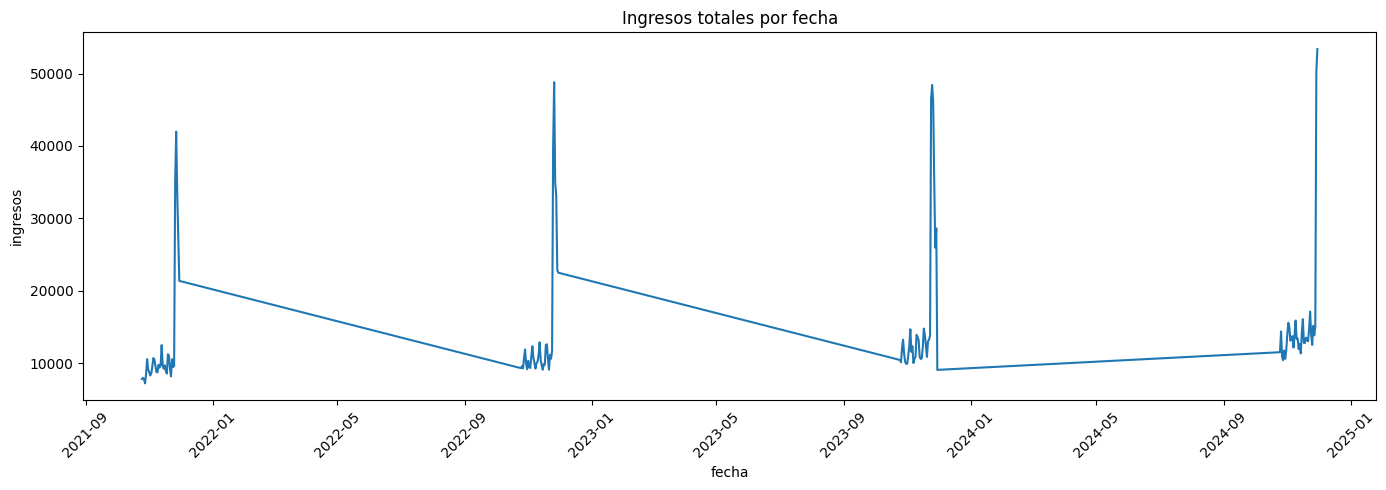

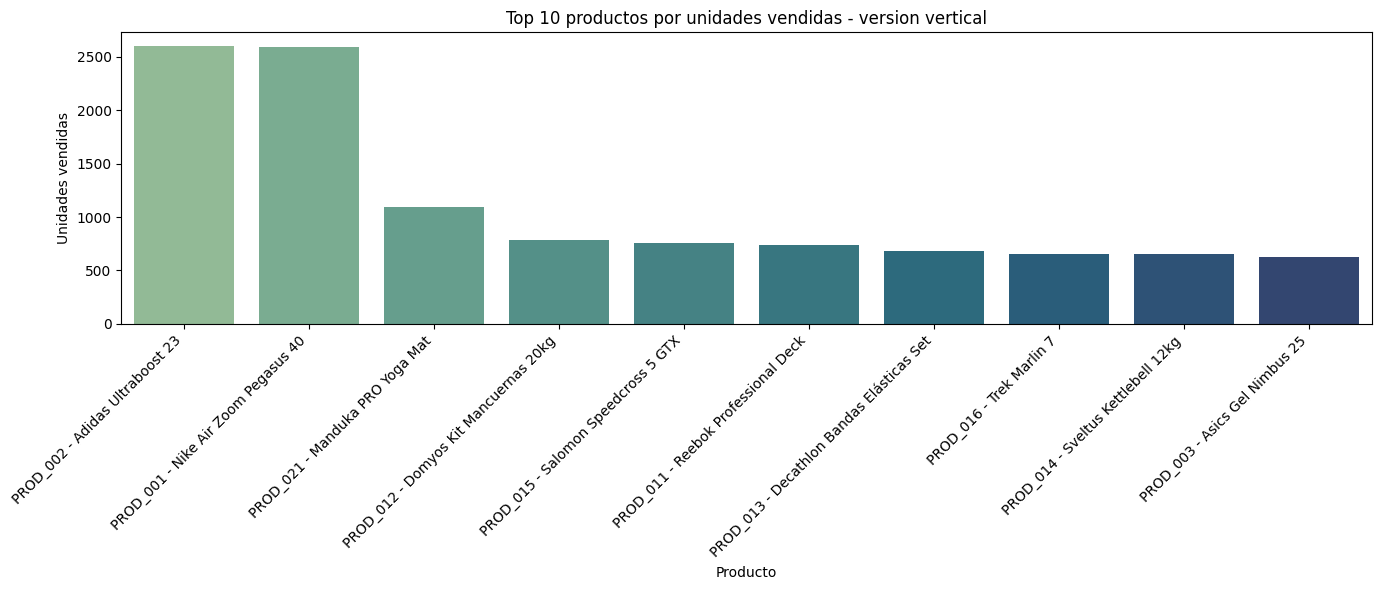

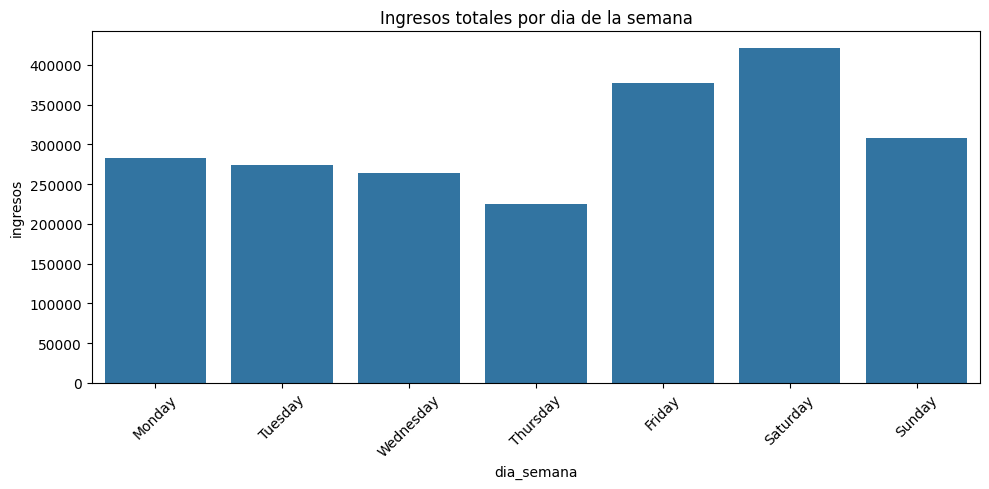

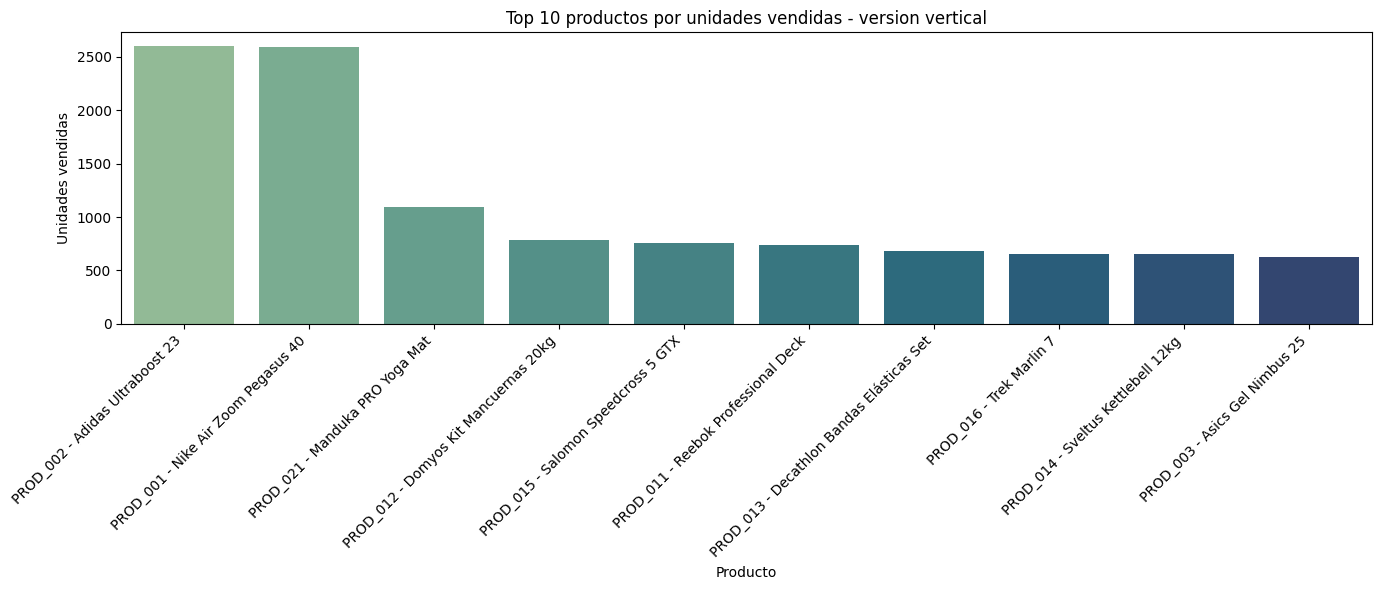

In [44]:
# Objetivo: preparar la variable fecha y construir una primera lectura temporal del negocio.
# Explicacion negocio: este bloque ayuda a responder cuando vendemos mas, como evoluciona
# la facturacion y si existe patron por dia de la semana o por mes.
ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'], errors='coerce')
competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'], errors='coerce')

print('Tipos de fecha convertidos:')
print('ventas_df[fecha]:', ventas_df['fecha'].dtype)
print('competencia_df[fecha]:', competencia_df['fecha'].dtype)

# Creamos una copia para enriquecerla con variables temporales sin tocar el dataset base.
ventas_temporal_df = ventas_df.copy()
ventas_temporal_df['anio'] = ventas_temporal_df['fecha'].dt.year
ventas_temporal_df['mes'] = ventas_temporal_df['fecha'].dt.month
ventas_temporal_df['dia_semana'] = ventas_temporal_df['fecha'].dt.day_name()

# Agregados temporales para resumir comportamiento diario, mensual y semanal.
ventas_por_fecha_df = ventas_temporal_df.groupby('fecha', as_index=False)[['unidades_vendidas', 'ingresos']].sum()
ventas_por_mes_df = ventas_temporal_df.groupby(['anio', 'mes'], as_index=False)[['unidades_vendidas', 'ingresos']].sum()
ventas_por_dia_semana_df = ventas_temporal_df.groupby('dia_semana', as_index=False)[['unidades_vendidas', 'ingresos']].sum()

# Ordenamos los dias para que la lectura visual siga la secuencia natural de la semana.
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_por_dia_semana_df['dia_semana'] = pd.Categorical(ventas_por_dia_semana_df['dia_semana'], categories=orden_dias, ordered=True)
ventas_por_dia_semana_df = ventas_por_dia_semana_df.sort_values('dia_semana')

print('Resumen temporal de ventas_df:')
print('Fechas unicas:', ventas_temporal_df['fecha'].nunique())
print('Primera fecha:', ventas_temporal_df['fecha'].min())
print('Ultima fecha:', ventas_temporal_df['fecha'].max())

# Tablas de apoyo para explicar el analisis antes de las graficas.
display(ventas_por_fecha_df.head())
display(ventas_por_mes_df.head())
display(ventas_por_dia_semana_df)

# Grafica 1: evolucion temporal de ingresos.
# Utilidad para negocio: detectar tendencia, estacionalidad y posibles picos o caidas anormales.
plt.figure(figsize=(14, 5))
sns.lineplot(data=ventas_por_fecha_df, x='fecha', y='ingresos')
plt.title('Ingresos totales por fecha')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Solo es una prueba: version alternativa en vertical.
plt.figure(figsize=(14, 6))
sns.barplot(data=top_productos_df, x='producto', y='unidades_vendidas', hue='producto', palette='crest', legend=False)
plt.title('Top 10 productos por unidades vendidas - version vertical')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Grafica 2: ingresos acumulados por dia de la semana.
# Utilidad para negocio: identificar dias fuertes y dias flojos para promociones, stock o personal.
plt.figure(figsize=(10, 5))
sns.barplot(data=ventas_por_dia_semana_df, x='dia_semana', y='ingresos')
plt.title('Ingresos totales por dia de la semana')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Solo es una prueba: version alternativa en vertical.
plt.figure(figsize=(14, 6))
sns.barplot(data=top_productos_df, x='producto', y='unidades_vendidas', hue='producto', palette='crest', legend=False)
plt.title('Top 10 productos por unidades vendidas - version vertical')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Union de fuentes
En esta parte combinamos ventas y competencia para construir una base unica lista para analisis avanzado o modelado predictivo.


In [45]:
# Objetivo: construir una tabla analitica unica para modelado y analisis conjunto.
# Explicacion negocio: esta union permite estudiar ventas propias junto con el contexto de precios
# de la competencia para cada producto y fecha.

# Usamos un cruce inner para conservar solo registros presentes en ambas fuentes.
# Claves de union: fecha y producto_id.
df = ventas_df.merge(competencia_df, on=['fecha', 'producto_id'], how='inner')

# Validaciones basicas tras la union.
print('df shape:', df.shape)
print('Columnas de df:')
display(df.columns.to_frame(index=False))

# Vista previa de la tabla final para confirmar que la union fue correcta.
display(df.head())


df shape: (3552, 13)
Columnas de df:


,0
0,fecha
1,producto_id
2,nombre
3,categoria
4,subcategoria
5,precio_base
6,es_estrella
7,unidades_vendidas
8,precio_venta
9,ingresos


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


## Analisis exploratorio de df
En esta seccion analizamos la tabla consolidada `df` para entender patrones de demanda, comportamiento por calendario y diferencias entre nuestro precio y el precio de referencia de Amazon.


In [46]:
# Objetivo: preparar variables auxiliares para el analisis exploratorio.
# Explicacion negocio: estas variables permiten leer mejor el comportamiento temporal,
# identificar eventos comerciales y segmentar el rendimiento por dimensiones de negocio.
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df['anio'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_semana'] = df['fecha'].dt.day_name()

def black_friday(fecha):
    return fecha.month == 11 and fecha.weekday() == 4 and 23 <= fecha.day <= 29

df['es_black_friday'] = df['fecha'].apply(black_friday)

print('df shape:', df.shape)
print('Anios disponibles:', sorted(df['anio'].dropna().unique().tolist()))
print('Black Friday detectados:', sorted(df.loc[df['es_black_friday'], 'fecha'].dt.strftime('%Y-%m-%d').unique().tolist()))


df shape: (3552, 17)
Anios disponibles: [2021, 2022, 2023, 2024]
Black Friday detectados: ['2021-11-26', '2022-11-25', '2023-11-24', '2024-11-29']


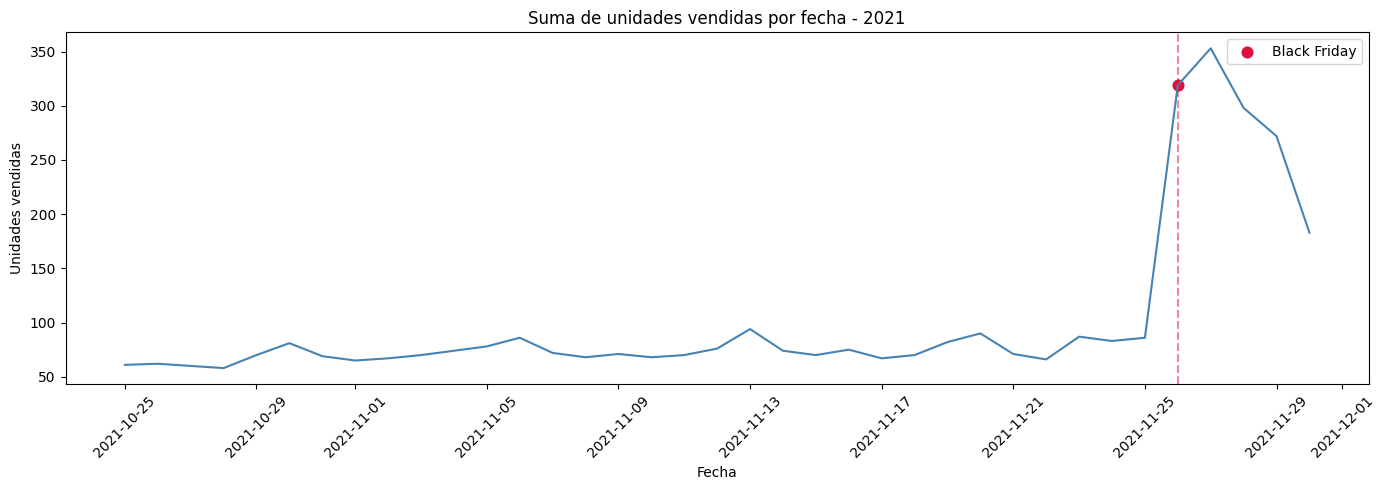

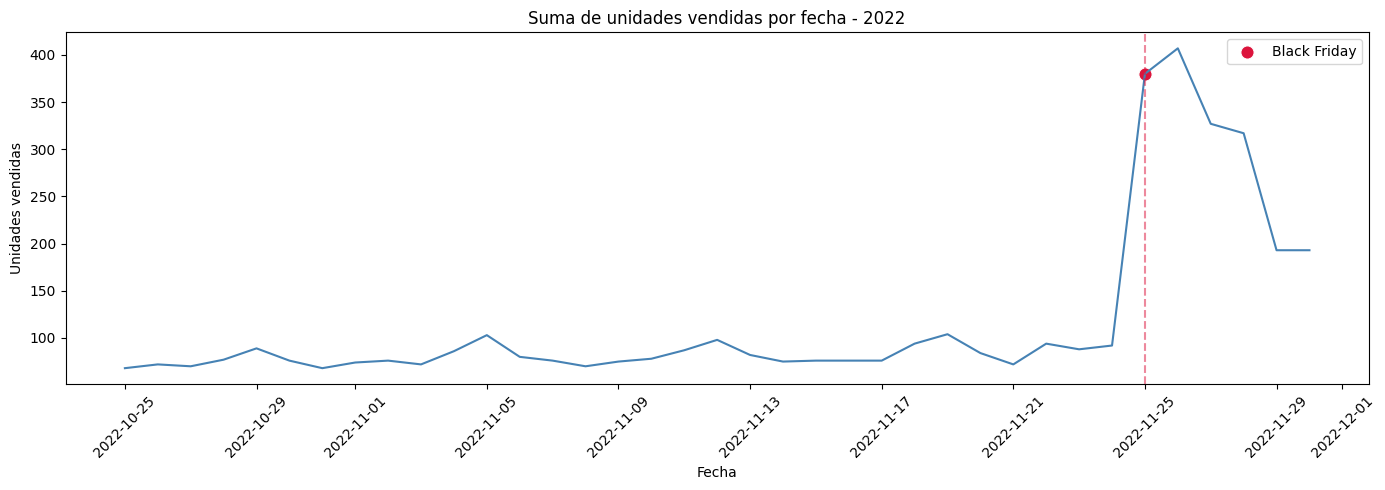

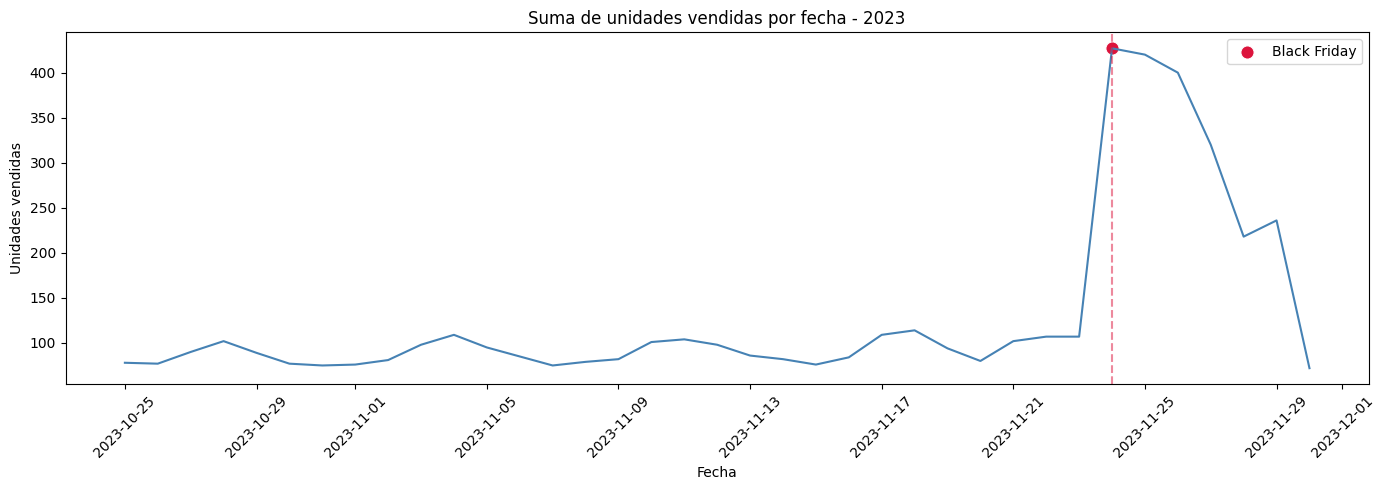

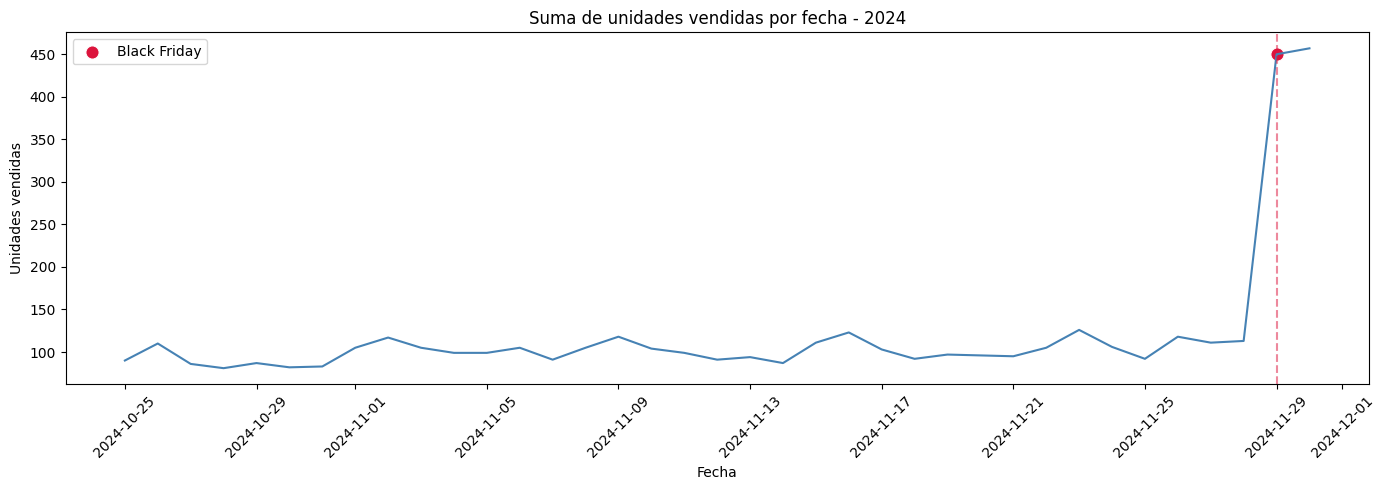

In [47]:
# Objetivo: visualizar la evolucion temporal de las unidades vendidas en cada anio.
# Explicacion negocio: este analisis ayuda a detectar estacionalidad, picos de demanda
# y el impacto de eventos comerciales como Black Friday.
ventas_anuales_df = (
    df.groupby(['anio', 'fecha'], as_index=False)['unidades_vendidas']
      .sum()
      .sort_values(['anio', 'fecha'])
)

black_friday_df = ventas_anuales_df[ventas_anuales_df['fecha'].apply(black_friday)].copy()

for anio in sorted(ventas_anuales_df['anio'].dropna().unique()):
    ventas_anio_df = ventas_anuales_df[ventas_anuales_df['anio'] == anio].copy()
    black_friday_anio_df = black_friday_df[black_friday_df['anio'] == anio].copy()

    plt.figure(figsize=(14, 5))
    sns.lineplot(data=ventas_anio_df, x='fecha', y='unidades_vendidas', color='steelblue')

    if not black_friday_anio_df.empty:
        sns.scatterplot(
            data=black_friday_anio_df,
            x='fecha',
            y='unidades_vendidas',
            color='crimson',
            s=90,
            label='Black Friday'
        )
        for _, fila in black_friday_anio_df.iterrows():
            plt.axvline(fila['fecha'], color='crimson', linestyle='--', alpha=0.5)

    plt.title(f'Suma de unidades vendidas por fecha - {anio}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


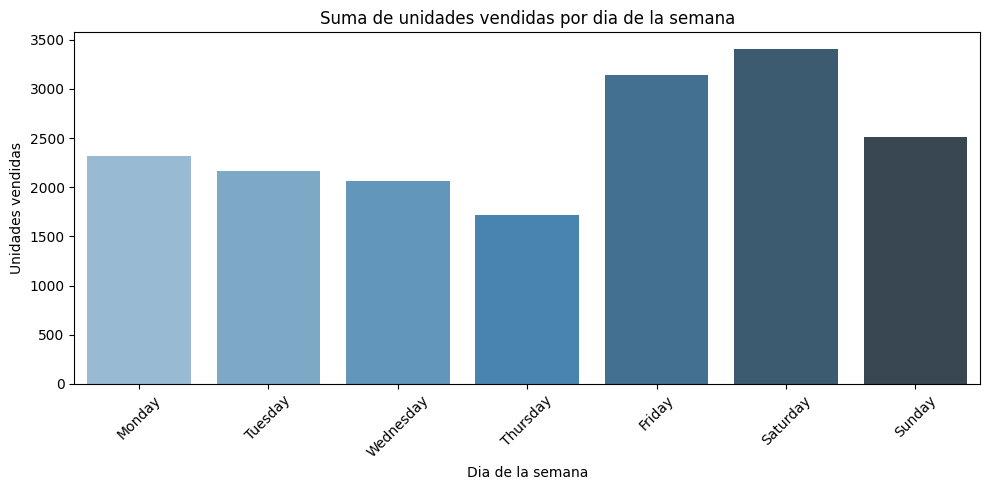

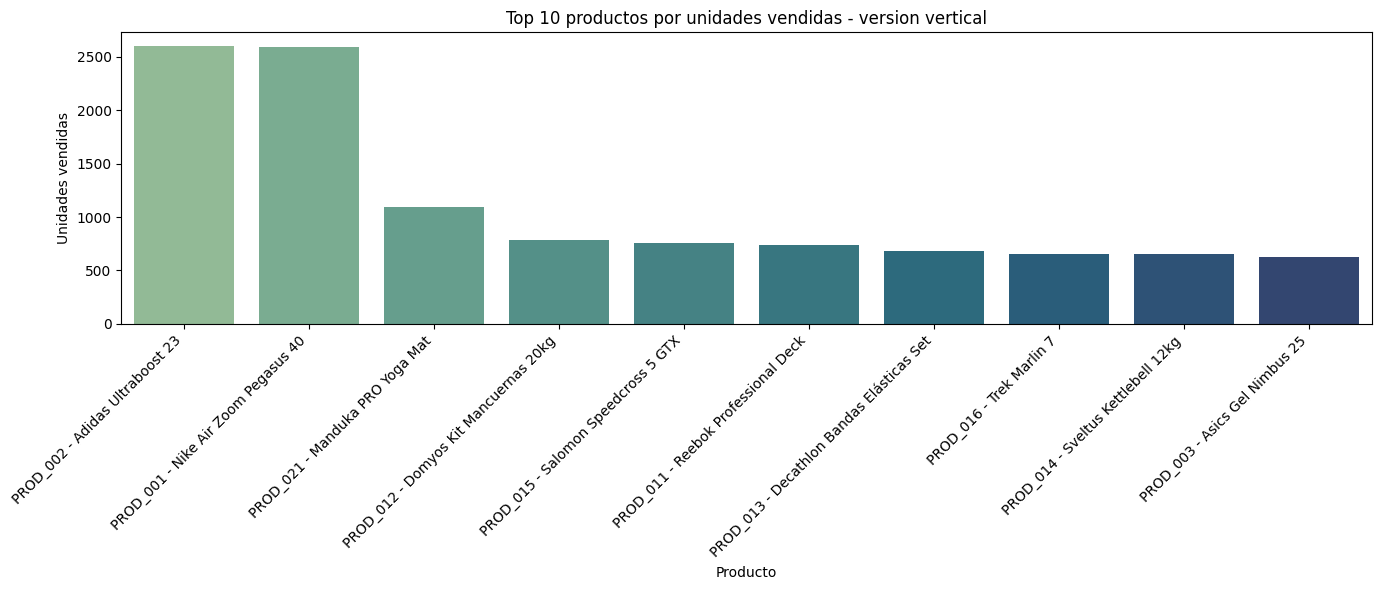

In [48]:
# Objetivo: comparar el volumen vendido por dia de la semana.
# Explicacion negocio: sirve para identificar dias fuertes y debiles en la demanda.
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_dia_semana_df = df.groupby('dia_semana', as_index=False)['unidades_vendidas'].sum()
ventas_dia_semana_df['dia_semana'] = pd.Categorical(ventas_dia_semana_df['dia_semana'], categories=orden_dias, ordered=True)
ventas_dia_semana_df = ventas_dia_semana_df.sort_values('dia_semana')

plt.figure(figsize=(10, 5))
sns.barplot(data=ventas_dia_semana_df, x='dia_semana', y='unidades_vendidas', hue='dia_semana', palette='Blues_d', legend=False)
plt.title('Suma de unidades vendidas por dia de la semana')
plt.xlabel('Dia de la semana')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Solo es una prueba: version alternativa en vertical.
plt.figure(figsize=(14, 6))
sns.barplot(data=top_productos_df, x='producto', y='unidades_vendidas', hue='producto', palette='crest', legend=False)
plt.title('Top 10 productos por unidades vendidas - version vertical')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


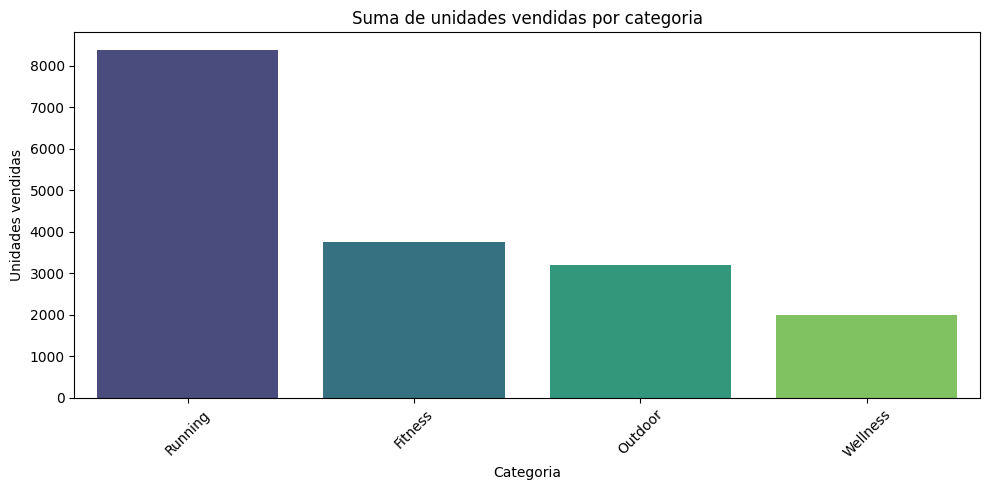

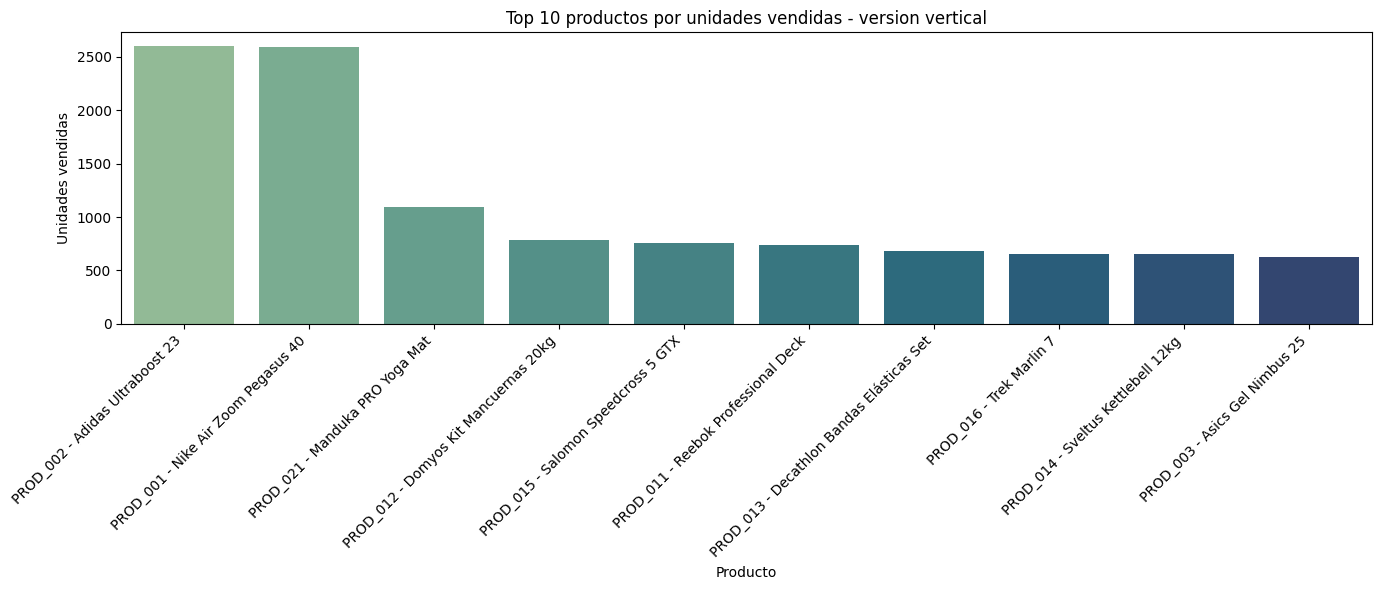

In [49]:
# Objetivo: entender que categorias concentran mas unidades vendidas.
# Explicacion negocio: ayuda a priorizar familias de producto en stock, marketing y forecasting.
ventas_categoria_df = df.groupby('categoria', as_index=False)['unidades_vendidas'].sum().sort_values('unidades_vendidas', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=ventas_categoria_df, x='categoria', y='unidades_vendidas', hue='categoria', palette='viridis', legend=False)
plt.title('Suma de unidades vendidas por categoria')
plt.xlabel('Categoria')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Solo es una prueba: version alternativa en vertical.
plt.figure(figsize=(14, 6))
sns.barplot(data=top_productos_df, x='producto', y='unidades_vendidas', hue='producto', palette='crest', legend=False)
plt.title('Top 10 productos por unidades vendidas - version vertical')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


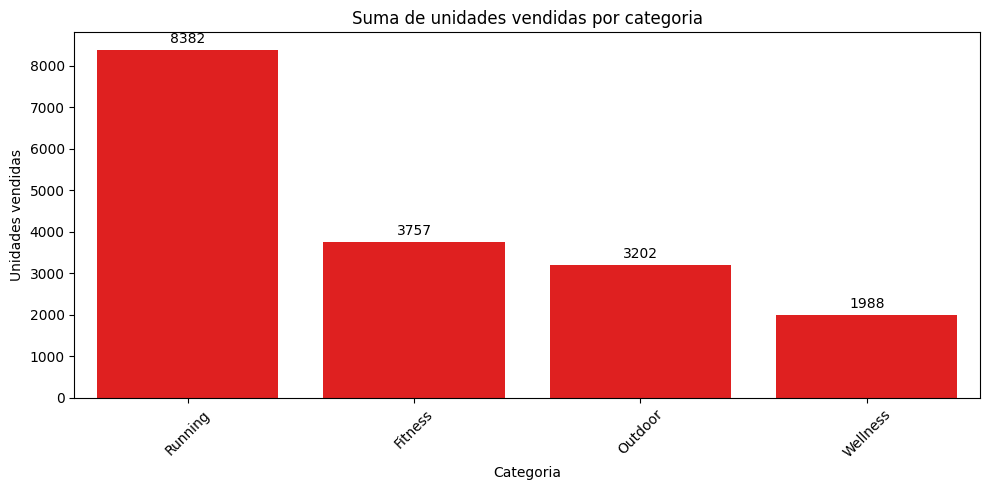

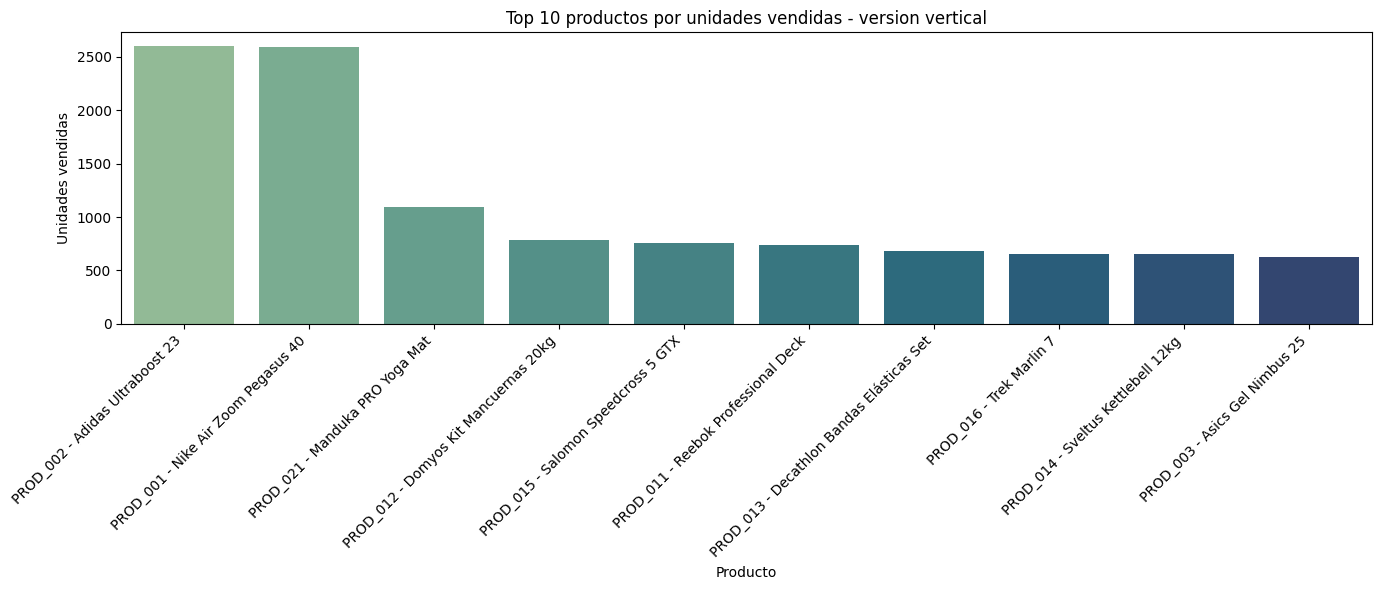

In [50]:
# Objetivo: entender que categorias concentran mas unidades vendidas.
# Explicacion negocio: ayuda a priorizar familias de producto en stock, marketing y forecasting.

# Aqui hacemos una version alternativa de la grafica anterior para mostrar como se pueden 
# personalizar los colores y aÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â±adir etiquetas con los valores exactos encima de cada barra, 
# lo que facilita la lectura y hace el grafico mas informativo.
ventas_categoria_df = (
    df.groupby('categoria', as_index=False)['unidades_vendidas']
    .sum()
    .sort_values('unidades_vendidas', ascending=False)
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=ventas_categoria_df,
    x='categoria',
    y='unidades_vendidas',
    color='red'
)

# AÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â±adimos la etiqueta con el valor encima de cada barra para facilitar la lectura.
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title('Suma de unidades vendidas por categoria')
plt.xlabel('Categoria')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Solo es una prueba: version alternativa en vertical.
plt.figure(figsize=(14, 6))
sns.barplot(data=top_productos_df, x='producto', y='unidades_vendidas', hue='producto', palette='crest', legend=False)
plt.title('Top 10 productos por unidades vendidas - version vertical')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


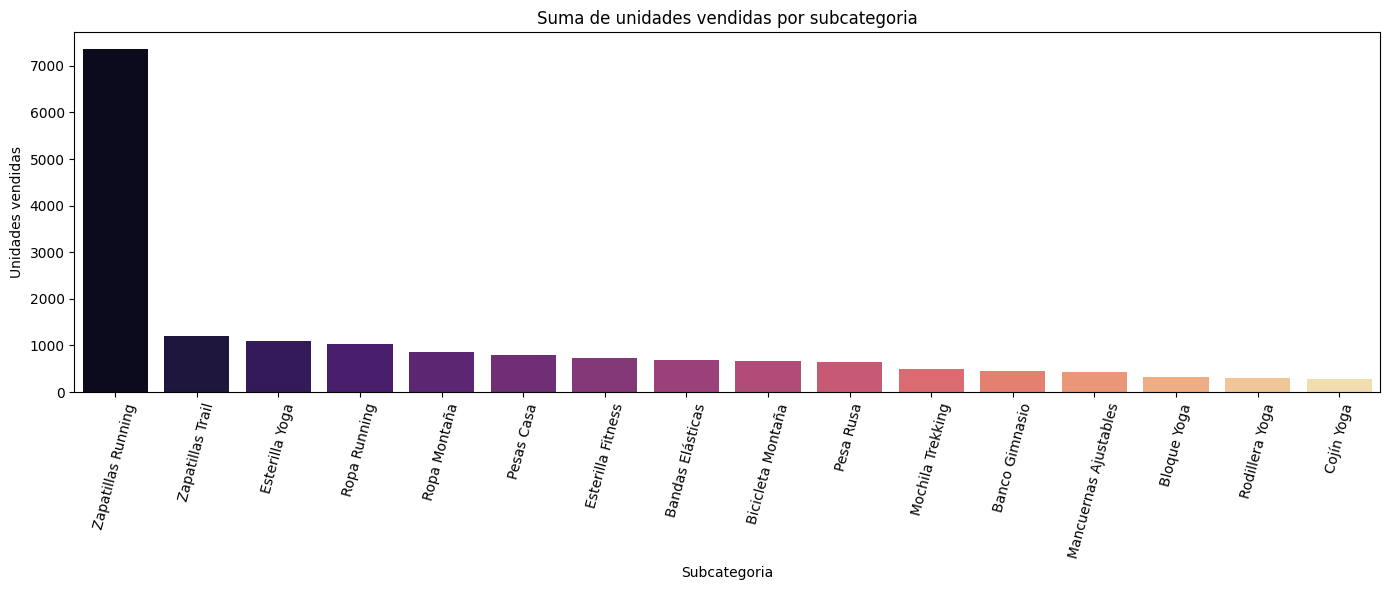

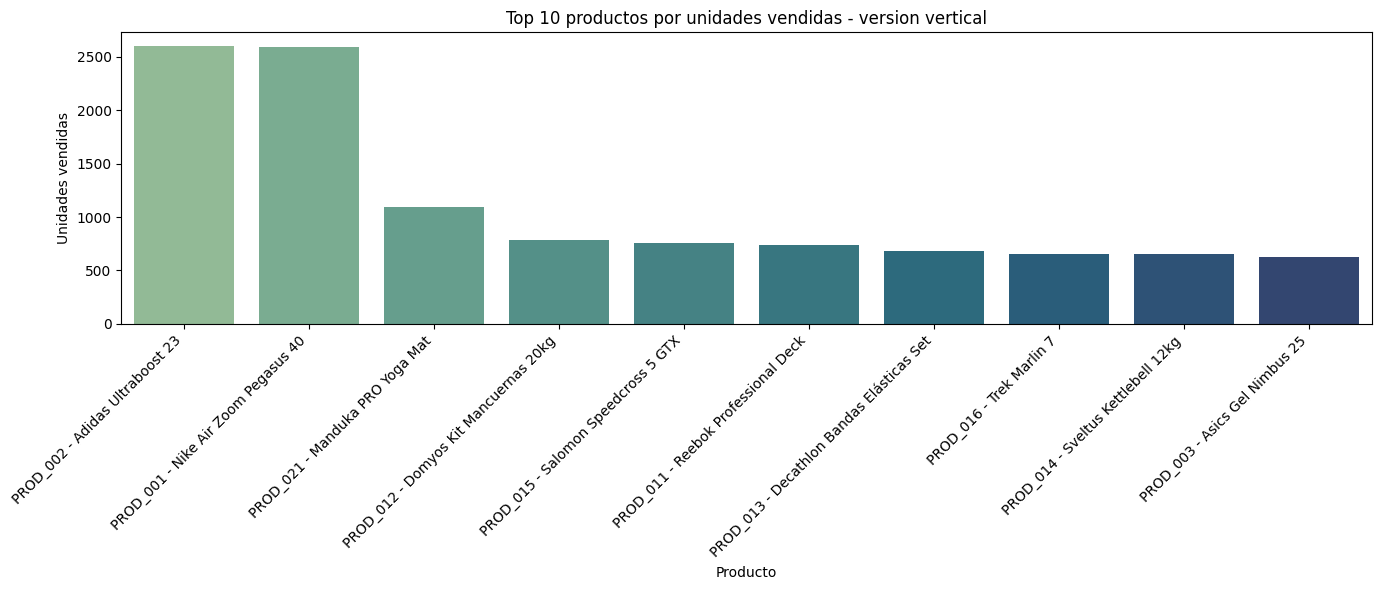

In [51]:
# Objetivo: bajar un nivel de detalle para ver que subcategorias mueven mas volumen.
# Explicacion negocio: permite identificar nichos concretos de demanda dentro de cada categoria.
ventas_subcategoria_df = df.groupby('subcategoria', as_index=False)['unidades_vendidas'].sum().sort_values('unidades_vendidas', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=ventas_subcategoria_df, x='subcategoria', y='unidades_vendidas', hue='subcategoria', palette='magma', legend=False)
plt.title('Suma de unidades vendidas por subcategoria')
plt.xlabel('Subcategoria')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# Solo es una prueba: version alternativa en vertical.
plt.figure(figsize=(14, 6))
sns.barplot(data=top_productos_df, x='producto', y='unidades_vendidas', hue='producto', palette='crest', legend=False)
plt.title('Top 10 productos por unidades vendidas - version vertical')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


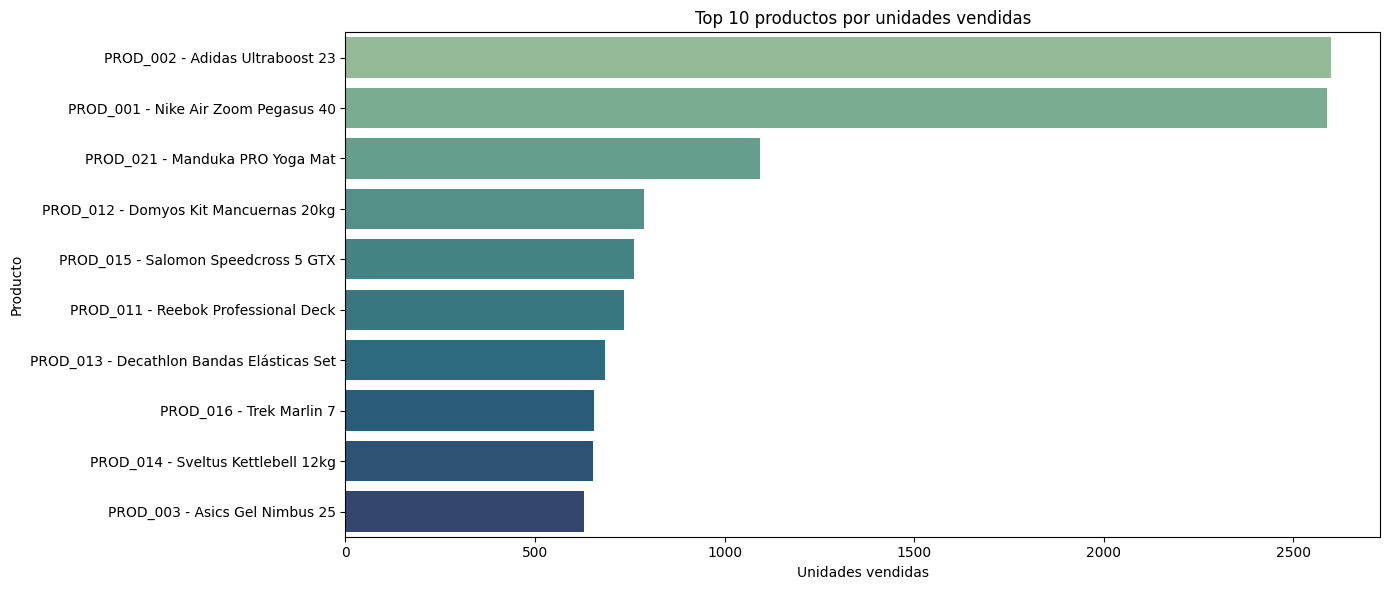

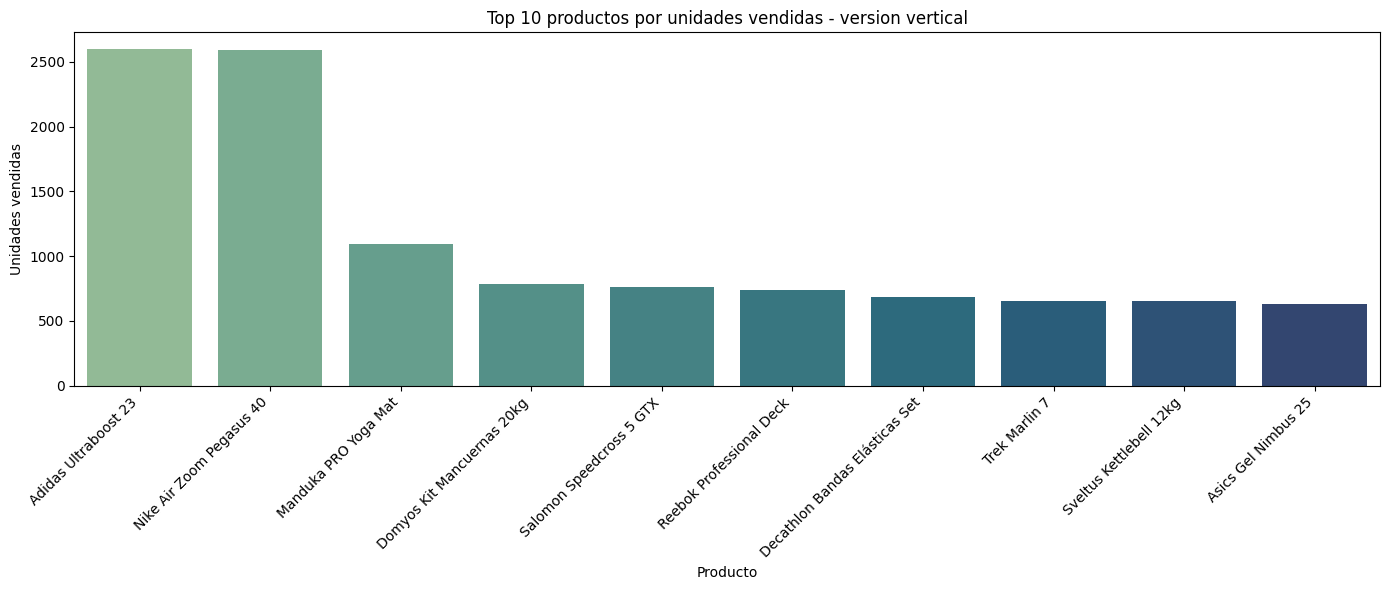

In [52]:
# Objetivo: identificar los productos que mas unidades aportan.
# Explicacion negocio: sirve para detectar referencias tractoras y posibles candidatos prioritarios.
top_productos_df = (
    df.groupby(['producto_id', 'nombre'], as_index=False)['unidades_vendidas']
      .sum()
      .sort_values('unidades_vendidas', ascending=False)
      .head(10)
)

top_productos_df['producto'] = top_productos_df['producto_id'] + ' - ' + top_productos_df['nombre']

plt.figure(figsize=(14, 6))
sns.barplot(data=top_productos_df, x='unidades_vendidas', y='producto', hue='producto', palette='crest', legend=False)
plt.title('Top 10 productos por unidades vendidas')
plt.xlabel('Unidades vendidas')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

# Solo es una prueba: version alternativa en vertical.
plt.figure(figsize=(14, 6))
#sns.barplot(data=top_productos_df, x='producto', y='unidades_vendidas', hue='producto', palette='crest', legend=False)
# cambiÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â© 'producto" por 'nombre' para mostrar solo el nombre del producto en el eje x, ya que la columna 'producto' ahora es una concatenacion de id y nombre.
sns.barplot(data=top_productos_df, x='nombre', y='unidades_vendidas', hue='nombre', palette='crest', legend=False)
plt.title('Top 10 productos por unidades vendidas - version vertical')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


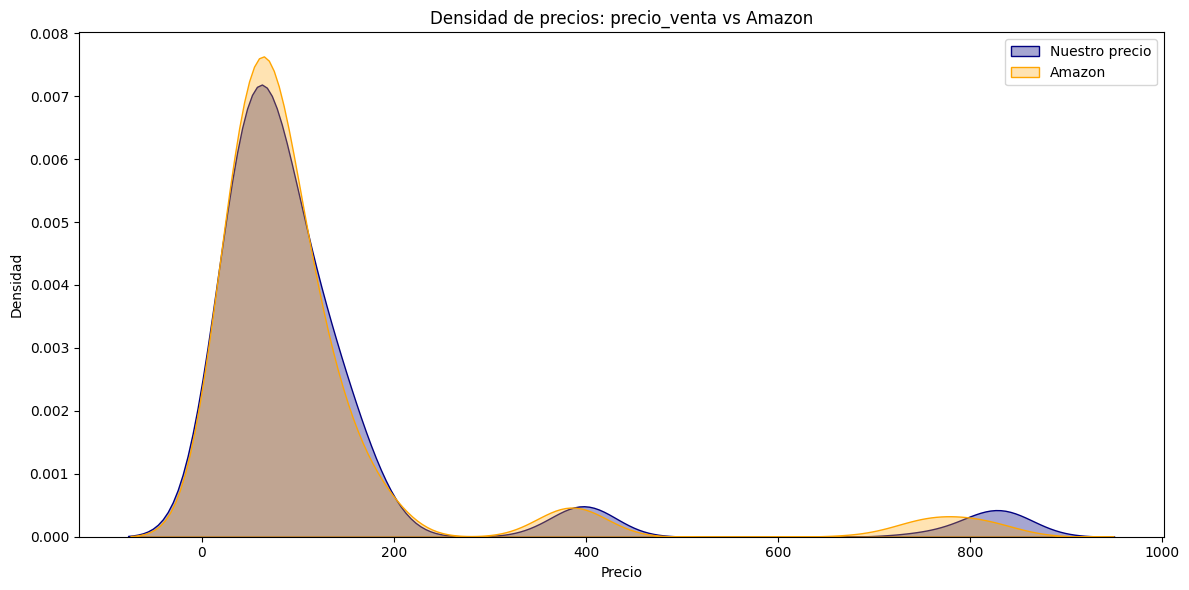

In [53]:
# Objetivo: comparar la distribucion de nuestro precio de venta frente al precio de Amazon.
# Explicacion negocio: ayuda a ver posicionamiento de precio, dispersion y posibles diferencias sistematicas.
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='precio_venta', fill=True, label='Nuestro precio', color='navy', alpha=0.35)
sns.kdeplot(data=df, x='Amazon', fill=True, label='Amazon', color='orange', alpha=0.30)
plt.title('Densidad de precios: precio_venta vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()


## Creacion de variables para el modelo
En esta seccion se crean variables temporales y de calendario para enriquecer el dataset antes del modelado.


In [54]:
# Objetivo: crear variables temporales y de calendario para preparar el modelo.
# Explicacion negocio: estas variables ayudan a capturar estacionalidad, festivos,
# eventos comerciales y patrones de compra asociados al calendario.
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')

def black_friday(fecha):
    return fecha.month == 11 and fecha.weekday() == 4 and 23 <= fecha.day <= 29

def cyber_monday(fecha):
    return fecha.month == 11 and fecha.weekday() == 0 and 26 <= fecha.day <= 30

anios_festivos = sorted(df['fecha'].dropna().dt.year.unique().tolist())
festivos_es = holidays.ES(years=anios_festivos)

df['anio'] = df['fecha'].dt.year
df['trimestre'] = df['fecha'].dt.quarter
df['mes'] = df['fecha'].dt.month
df['nombre_mes'] = df['fecha'].dt.month_name()
df['dia'] = df['fecha'].dt.day
df['dia_anio'] = df['fecha'].dt.dayofyear
df['semana_anio'] = df['fecha'].dt.isocalendar().week.astype(int)
df['dia_semana_num'] = df['fecha'].dt.weekday
df['dia_semana'] = df['fecha'].dt.day_name()
df['es_fin_de_semana'] = df['dia_semana_num'].isin([5, 6])
df['es_inicio_mes'] = df['fecha'].dt.is_month_start
df['es_fin_mes'] = df['fecha'].dt.is_month_end
df['es_inicio_trimestre'] = df['fecha'].dt.is_quarter_start
df['es_fin_trimestre'] = df['fecha'].dt.is_quarter_end
df['es_inicio_anio'] = df['fecha'].dt.is_year_start
df['es_fin_anio'] = df['fecha'].dt.is_year_end
df['es_primera_quincena'] = df['dia'] <= 15
df['es_ultima_quincena'] = df['dia'] > 15
df['es_payday_inicio_mes'] = df['dia'].between(1, 5)
df['es_payday_fin_mes'] = df['dia'] >= 25
df['es_festivo'] = df['fecha'].dt.date.isin(festivos_es)
df['nombre_festivo'] = df['fecha'].dt.date.map(lambda fecha: festivos_es.get(fecha))
df['es_vispera_festivo'] = df['fecha'].add(pd.Timedelta(days=1)).dt.date.isin(festivos_es)
df['es_post_festivo'] = df['fecha'].sub(pd.Timedelta(days=1)).dt.date.isin(festivos_es)
df['es_black_friday'] = df['fecha'].apply(black_friday)
df['es_cyber_monday'] = df['fecha'].apply(cyber_monday)
df['dias_hasta_fin_mes'] = df['fecha'].dt.days_in_month - df['dia']
df['semana_mes'] = ((df['dia'] - 1) // 7) + 1
df['temporada_rebajas_invierno'] = ((df['mes'] == 1) | ((df['mes'] == 2) & (df['dia'] <= 15)))
df['temporada_rebajas_verano'] = ((df['mes'] == 7) | ((df['mes'] == 8) & (df['dia'] <= 15)))
df['campana_navidad'] = ((df['mes'] == 12) | ((df['mes'] == 1) & (df['dia'] <= 6)))
df['campana_vuelta_al_cole'] = ((df['mes'] == 8) & (df['dia'] >= 15)) | (df['mes'] == 9)
df['es_puente'] = (~df['es_festivo']) & (
    df['fecha'].add(pd.Timedelta(days=1)).dt.date.isin(festivos_es)
    | df['fecha'].sub(pd.Timedelta(days=1)).dt.date.isin(festivos_es)
 )

features_temporales = [
    'anio', 'trimestre', 'mes', 'nombre_mes', 'dia', 'dia_anio', 'semana_anio',
    'dia_semana_num', 'dia_semana', 'es_fin_de_semana', 'es_inicio_mes', 'es_fin_mes',
    'es_inicio_trimestre', 'es_fin_trimestre', 'es_inicio_anio', 'es_fin_anio',
    'es_primera_quincena', 'es_ultima_quincena', 'es_payday_inicio_mes', 'es_payday_fin_mes',
    'es_festivo', 'nombre_festivo', 'es_vispera_festivo', 'es_post_festivo',
    'es_black_friday', 'es_cyber_monday', 'dias_hasta_fin_mes', 'semana_mes',
    'temporada_rebajas_invierno', 'temporada_rebajas_verano', 'campana_navidad',
    'campana_vuelta_al_cole', 'es_puente'
]

#pd.set_option('display.max_columns', None)
print('Variables temporales creadas:', len(features_temporales))
display(df[['fecha'] + features_temporales].head())


Variables temporales creadas: 33


,fecha,anio,trimestre,mes,nombre_mes,dia,dia_anio,semana_anio,dia_semana_num,dia_semana,es_fin_de_semana,es_inicio_mes,es_fin_mes,es_inicio_trimestre,es_fin_trimestre,es_inicio_anio,es_fin_anio,es_primera_quincena,es_ultima_quincena,es_payday_inicio_mes,es_payday_fin_mes,es_festivo,nombre_festivo,es_vispera_festivo,es_post_festivo,es_black_friday,es_cyber_monday,dias_hasta_fin_mes,semana_mes,temporada_rebajas_invierno,temporada_rebajas_verano,campana_navidad,campana_vuelta_al_cole,es_puente
0,2021-10-25,2021,4,10,October,25,298,43,0,Monday,False,False,False,False,False,False,False,False,True,False,True,False,None,False,False,False,False,6,4,False,False,False,False,False
1,2021-10-25,2021,4,10,October,25,298,43,0,Monday,False,False,False,False,False,False,False,False,True,False,True,False,None,False,False,False,False,6,4,False,False,False,False,False
2,2021-10-25,2021,4,10,October,25,298,43,0,Monday,False,False,False,False,False,False,False,False,True,False,True,False,None,False,False,False,False,6,4,False,False,False,False,False
3,2021-10-25,2021,4,10,October,25,298,43,0,Monday,False,False,False,False,False,False,False,False,True,False,True,False,None,False,False,False,False,6,4,False,False,False,False,False
4,2021-10-25,2021,4,10,October,25,298,43,0,Monday,False,False,False,False,False,False,False,False,True,False,True,False,None,False,False,False,False,6,4,False,False,False,False,False


In [55]:
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage,anio,mes,dia_semana,es_black_friday,trimestre,nombre_mes,dia,dia_anio,semana_anio,dia_semana_num,es_fin_de_semana,es_inicio_mes,es_fin_mes,es_inicio_trimestre,es_fin_trimestre,es_inicio_anio,es_fin_anio,es_primera_quincena,es_ultima_quincena,es_payday_inicio_mes,es_payday_fin_mes,es_festivo,nombre_festivo,es_vispera_festivo,es_post_festivo,es_cyber_monday,dias_hasta_fin_mes,semana_mes,temporada_rebajas_invierno,temporada_rebajas_verano,campana_navidad,campana_vuelta_al_cole,es_puente
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43,2021,10,Monday,False,4,October,25,298,43,0,False,False,False,False,False,False,False,False,True,False,True,False,None,False,False,False,6,4,False,False,False,False,False
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58,2021,10,Monday,False,4,October,25,298,43,0,False,False,False,False,False,False,False,False,True,False,True,False,None,False,False,False,6,4,False,False,False,False,False
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11,2021,10,Monday,False,4,October,25,298,43,0,False,False,False,False,False,False,False,False,True,False,True,False,None,False,False,False,6,4,False,False,False,False,False
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45,2021,10,Monday,False,4,October,25,298,43,0,False,False,False,False,False,False,False,False,True,False,True,False,None,False,False,False,6,4,False,False,False,False,False
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07,2021,10,Monday,False,4,October,25,298,43,0,False,False,False,False,False,False,False,False,True,False,True,False,None,False,False,False,6,4,False,False,False,False,False


In [56]:
# Para ver la lista completa de variables temporales creadas, podemos mostrar el nombre de cada una:
pd.DataFrame(features_temporales, columns=['feature_temporal'])

,feature_temporal
0,anio
1,trimestre
2,mes
3,nombre_mes
4,dia
5,dia_anio
6,semana_anio
7,dia_semana_num
8,dia_semana
9,es_fin_de_semana


In [57]:
# Objetivo: crear lags de unidades_vendidas para capturar el efecto de ventas recientes.
# Explicacion negocio: ayuda al modelo a aprender la inercia de la demanda sin mezclar periodos de anos distintos.
df = df.sort_values(['producto_id', 'anio', 'fecha']).copy()

lags_unidades = [f'lag_{i}' for i in range(1, 8)]

for i in range(1, 8):
    df[f'lag_{i}'] = df.groupby(['producto_id', 'anio'])['unidades_vendidas'].shift(i)

display(df[['fecha', 'producto_id', 'anio', 'unidades_vendidas'] + lags_unidades].head(10))


,fecha,producto_id,anio,unidades_vendidas,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
0,2021-10-25,PROD_001,2021,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,2021-10-26,PROD_001,2021,8,6.0,NaN,NaN,NaN,NaN,NaN,NaN
48,2021-10-27,PROD_001,2021,8,8.0,6.0,NaN,NaN,NaN,NaN,NaN
72,2021-10-28,PROD_001,2021,7,8.0,8.0,6.0,NaN,NaN,NaN,NaN
96,2021-10-29,PROD_001,2021,12,7.0,8.0,8.0,6.0,NaN,NaN,NaN
120,2021-10-30,PROD_001,2021,12,12.0,7.0,8.0,8.0,6.0,NaN,NaN
144,2021-10-31,PROD_001,2021,9,12.0,12.0,7.0,8.0,8.0,6.0,NaN
168,2021-11-01,PROD_001,2021,7,9.0,12.0,12.0,7.0,8.0,8.0,6.0
192,2021-11-02,PROD_001,2021,10,7.0,9.0,12.0,12.0,7.0,8.0,8.0
216,2021-11-03,PROD_001,2021,11,10.0,7.0,9.0,12.0,12.0,7.0,8.0


In [58]:
df.shape

(3552, 53)

In [62]:
# Objetivo: crear una media movil de 7 dias para suavizar la serie y captar tendencia reciente.
# Explicacion negocio: resume el comportamiento reciente de ventas por producto sin mezclar anos diferentes.
df = df.sort_values(['producto_id', 'anio', 'fecha']).copy()

df['media_movil_7_dias'] = (
    df.groupby(['producto_id', 'anio'])['unidades_vendidas']
      .transform(lambda serie: serie.shift(1).rolling(window=7, min_periods=7).mean())
 )

nuevas_variables_lag = [f'lag_{i}' for i in range(1, 8)] + ['media_movil_7_dias']
df_modelo = df.dropna(subset=nuevas_variables_lag).copy()

print('Variables creadas:', nuevas_variables_lag)
print('Filas originales:', len(df))
print('Filas despues de eliminar nulos:', len(df_modelo))
display(df_modelo[['fecha', 'producto_id', 'anio', 'unidades_vendidas'] + nuevas_variables_lag].head(10))


Variables creadas: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'media_movil_7_dias']
Filas originales: 3552
Filas despues de eliminar nulos: 2880


,fecha,producto_id,anio,unidades_vendidas,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,media_movil_7_dias
168,2021-11-01,PROD_001,2021,7,9.0,12.0,12.0,7.0,8.0,8.0,6.0,8.857143
192,2021-11-02,PROD_001,2021,10,7.0,9.0,12.0,12.0,7.0,8.0,8.0,9.000000
216,2021-11-03,PROD_001,2021,11,10.0,7.0,9.0,12.0,12.0,7.0,8.0,9.285714
240,2021-11-04,PROD_001,2021,12,11.0,10.0,7.0,9.0,12.0,12.0,7.0,9.714286
264,2021-11-05,PROD_001,2021,10,12.0,11.0,10.0,7.0,9.0,12.0,12.0,10.428571
288,2021-11-06,PROD_001,2021,10,10.0,12.0,11.0,10.0,7.0,9.0,12.0,10.142857
312,2021-11-07,PROD_001,2021,10,10.0,10.0,12.0,11.0,10.0,7.0,9.0,9.857143
336,2021-11-08,PROD_001,2021,9,10.0,10.0,10.0,12.0,11.0,10.0,7.0,10.000000
360,2021-11-09,PROD_001,2021,11,9.0,10.0,10.0,10.0,12.0,11.0,10.0,10.285714
384,2021-11-10,PROD_001,2021,10,11.0,9.0,10.0,10.0,10.0,12.0,11.0,10.428571


In [68]:
# Validacion: revisar por ano las unidades vendidas y sus lags para comprobar que no se mezclan periodos.
columnas_lags = ['fecha', 'anio', 'producto_id', 'unidades_vendidas'] + [f'lag_{i}' for i in range(1, 8)]
df_modelo[columnas_lags].sort_values(['anio', 'producto_id', 'fecha']).head(20)


,fecha,anio,producto_id,unidades_vendidas,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
168,2021-11-01,2021,PROD_001,7,9.0,12.0,12.0,7.0,8.0,8.0,6.0
192,2021-11-02,2021,PROD_001,10,7.0,9.0,12.0,12.0,7.0,8.0,8.0
216,2021-11-03,2021,PROD_001,11,10.0,7.0,9.0,12.0,12.0,7.0,8.0
240,2021-11-04,2021,PROD_001,12,11.0,10.0,7.0,9.0,12.0,12.0,7.0
264,2021-11-05,2021,PROD_001,10,12.0,11.0,10.0,7.0,9.0,12.0,12.0
288,2021-11-06,2021,PROD_001,10,10.0,12.0,11.0,10.0,7.0,9.0,12.0
312,2021-11-07,2021,PROD_001,10,10.0,10.0,12.0,11.0,10.0,7.0,9.0
336,2021-11-08,2021,PROD_001,9,10.0,10.0,10.0,12.0,11.0,10.0,7.0
360,2021-11-09,2021,PROD_001,11,9.0,10.0,10.0,10.0,12.0,11.0,10.0
384,2021-11-10,2021,PROD_001,10,11.0,9.0,10.0,10.0,10.0,12.0,11.0


In [65]:
df_modelo.shape

(2880, 54)

In [67]:
df.groupby('anio').size()

anio
2021    888
2022    888
2023    888
2024    888
dtype: int64

In [71]:
# Objetivo: crear el porcentaje de descuento respecto al precio base.
# Explicacion negocio: ayuda a medir la intensidad promocional de cada venta.
df['descuento_porcentaje'] = ((df['precio_venta'] - df['precio_base']) / df['precio_base']) * 100

df[['fecha', 'producto_id', 'precio_base', 'precio_venta', 'descuento_porcentaje']].head()


,fecha,producto_id,precio_base,precio_venta,descuento_porcentaje
0,2021-10-25,PROD_001,115,118.36,2.921739
24,2021-10-26,PROD_001,115,117.37,2.060870
48,2021-10-27,PROD_001,115,114.27,-0.634783
72,2021-10-28,PROD_001,115,118.14,2.730435
96,2021-10-29,PROD_001,115,117.23,1.939130


In [76]:
# Objetivo: resumir el precio de la competencia en una sola variable y compararlo con nuestro precio.
# Explicacion negocio: ayuda a medir posicionamiento de precio frente al mercado de forma simple.
columnas_competencia = ['Amazon', 'Decathlon', 'Deporvillage']
columnas_disponibles = [col for col in columnas_competencia if col in df.columns]

if len(columnas_disponibles) == len(columnas_competencia):
    df['precio_competencia'] = df[columnas_disponibles].mean(axis=1)
    df['ratio_precio'] = df['precio_venta'] / df['precio_competencia']
    df = df.drop(columns=columnas_competencia)
elif 'precio_competencia' in df.columns and 'ratio_precio' in df.columns:
    print('Las variables precio_competencia y ratio_precio ya fueron creadas, y las columnas de competencia ya no estan en df.')
else:
    raise KeyError(f'No se encontraron todas las columnas de competencia esperadas: {columnas_competencia}')

df[['fecha', 'producto_id', 'precio_venta', 'precio_competencia', 'ratio_precio']].head(30)


Las variables precio_competencia y ratio_precio ya fueron creadas, y las columnas de competencia ya no estan en df.


,fecha,producto_id,precio_venta,precio_competencia,ratio_precio
0,2021-10-25,PROD_001,118.36,97.423333,1.214904
24,2021-10-26,PROD_001,117.37,96.596667,1.215052
48,2021-10-27,PROD_001,114.27,96.616667,1.182715
72,2021-10-28,PROD_001,118.14,95.976667,1.230924
96,2021-10-29,PROD_001,117.23,96.213333,1.218438
120,2021-10-30,PROD_001,118.41,95.690000,1.237433
144,2021-10-31,PROD_001,112.99,95.723333,1.180381
168,2021-11-01,PROD_001,115.07,95.353333,1.206775
192,2021-11-02,PROD_001,116.10,96.153333,1.207446
216,2021-11-03,PROD_001,114.58,95.240000,1.203066


## One Hot Encoding
En esta secciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n empezamos la codificaciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n de variables categÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³ricas para preparar el modelo. Primero creamos copias de 
ombre, categoria y subcategoria con sufijo _h, y despuÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©s aplicamos one hot encoding sobre esas copias.


In [80]:
# Objetivo: preparar variables categÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³ricas para el modelo mediante one hot encoding.
# ExplicaciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n negocio: permite que el modelo utilice nombre, categorÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­a y subcategorÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­a en formato numÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©rico.
df['nombre_h'] = df['nombre']
df['categoria_h'] = df['categoria']
df['subcategoria_h'] = df['subcategoria']

columnas_ohe = ['nombre_h', 'categoria_h', 'subcategoria_h']
df = pd.get_dummies(df, columns=columnas_ohe, dtype=int)

df.filter(regex='^(nombre_h_|categoria_h_|subcategoria_h_)').head()


,nombre_h_Adidas Own The Run Jacket,nombre_h_Adidas Ultraboost 23,nombre_h_Asics Gel Nimbus 25,nombre_h_Bowflex SelectTech 552,nombre_h_Columbia Silver Ridge,nombre_h_Decathlon Bandas ElÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡sticas Set,nombre_h_Domyos BM900,nombre_h_Domyos Kit Mancuernas 20kg,nombre_h_Gaiam Premium Yoga Block,nombre_h_Liforme Yoga Pad,nombre_h_Lotuscrafts Yoga Bolster,nombre_h_Manduka PRO Yoga Mat,nombre_h_Merrell Moab 2 GTX,nombre_h_New Balance Fresh Foam X 1080v12,nombre_h_Nike Air Zoom Pegasus 40,nombre_h_Nike Dri-FIT Miler,nombre_h_Puma Velocity Nitro 2,nombre_h_Quechua MH500,nombre_h_Reebok Floatride Energy 5,nombre_h_Reebok Professional Deck,nombre_h_Salomon Speedcross 5 GTX,nombre_h_Sveltus Kettlebell 12kg,nombre_h_The North Face Borealis,nombre_h_Trek Marlin 7,categoria_h_Fitness,categoria_h_Outdoor,categoria_h_Running,categoria_h_Wellness,subcategoria_h_Banco Gimnasio,subcategoria_h_Bandas ElÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡sticas,subcategoria_h_Bicicleta MontaÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â±a,subcategoria_h_Bloque Yoga,subcategoria_h_CojÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­n Yoga,subcategoria_h_Esterilla Fitness,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa MontaÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â±a,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail,nombre_h_Adidas Own The Run Jacket,nombre_h_Adidas Ultraboost 23,nombre_h_Asics Gel Nimbus 25,nombre_h_Bowflex SelectTech 552,nombre_h_Columbia Silver Ridge,nombre_h_Decathlon Bandas ElÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬

In [ ]:
#df.head(30)
df.tail(30)

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,anio,mes,dia_semana,es_black_friday,trimestre,nombre_mes,dia,dia_anio,semana_anio,dia_semana_num,es_fin_de_semana,es_inicio_mes,es_fin_mes,es_inicio_trimestre,es_fin_trimestre,es_inicio_anio,es_fin_anio,es_primera_quincena,es_ultima_quincena,es_payday_inicio_mes,es_payday_fin_mes,es_festivo,nombre_festivo,es_vispera_festivo,es_post_festivo,es_cyber_monday,dias_hasta_fin_mes,semana_mes,temporada_rebajas_invierno,temporada_rebajas_verano,campana_navidad,campana_vuelta_al_cole,es_puente,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,media_movil_7_dias,descuento_porcentaje,precio_competencia,ratio_precio,nombre_h_Adidas Own The Run Jacket,nombre_h_Adidas Ultraboost 23,nombre_h_Asics Gel Nimbus 25,nombre_h_Bowflex SelectTech 552,nombre_h_Columbia Silver Ridge,nombre_h_Decathlon Bandas ElÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡sticas Set,nombre_h_Domyos BM900,nombre_h_Domyos Kit Mancuernas 20kg,nombre_h_Gaiam Premium Yoga Block,nombre_h_Liforme Yoga Pad,nombre_h_Lotuscrafts Yoga Bolster,nombre_h_Manduka PRO Yoga Mat,nombre_h_Merrell Moab 2 GTX,nombre_h_New Balance Fresh Foam X 1080v12,nombre_h_Nike Air Zoom Pegasus 40,nombre_h_Nike Dri-FIT Miler,nombre_h_Puma Velocity Nitro 2,nombre_h_Quechua MH500,nombre_h_Reebok Floatride Energy 5,nombre_h_Reebok Professional Deck,nombre_h_Salomon Speedcross 5 GTX,nombre_h_Sveltus Kettlebell 12kg,nombre_h_The North Face Borealis,nombre_h_Trek Marlin 7,categoria_h_Fitness,categoria_h_Outdoor,categoria_h_Running,categoria_h_Wellness,subcategoria_h_Banco Gimnasio,subcategoria_h_Bandas ElÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡sticas,subcategoria_h_Bicicleta MontaÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â±a,subcategoria_h_Bloque Yoga,subcategoria_h_CojÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¾Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­n Yoga,subcategoria_h_Esterilla Fitness,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa MontaÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â

In [90]:
# Objetivo: guardar el dataframe procesado para reutilizarlo en el modelado.
from pathlib import Path

ruta_salida = Path('data/processed/df.csv')
ruta_salida.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(ruta_salida, index=False)

print(f'DataFrame guardado en: {ruta_salida}')


DataFrame guardado en: data\processed\df.csv


## Modelo
En esta secciÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â³n empezamos a preparar el conjunto de entrenamiento y validaciÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â³n con un corte temporal para respetar el orden cronolÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â³gico de los datos.


In [ ]:
# Objetivo: separar los datos en entrenamiento y validaciÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â³n siguiendo el tiempo.
# ExplicaciÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â³n negocio: entrenamos con 2021 a 2023 y validamos con 2024 para simular un escenario real de predicciÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â³n futura.
train_df = df[df['anio'].between(2021, 2023)].copy()
validation_df = df[df['anio'] == 2024].copy()

print(f'Registros en train_df: {len(train_df)}')
print(f'Registros en validation_df: {len(validation_df)}')


### Entrenamiento del modelo
En esta subsecciÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â³n entrenamos un HistGradientBoostingRegressor con parÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¡metros conservadores y comparamos su rendimiento frente a una baseline naive basada en la media del conjunto de entrenamiento.


In [93]:
# Objetivo: entrenar un modelo de boosting conservador y compararlo con una baseline naive.
# Importamos el modelo y las mÃƒÆ’Ã‚Â©tricas que vamos a necesitar.
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Creamos un alias en espaÃƒÆ’Ã‚Â±ol para que el bloque sea mÃƒÆ’Ã‚Â¡s fÃƒÆ’Ã‚Â¡cil de leer.
validacion_df = validation_df.copy()

# Definimos la variable objetivo: es lo que queremos predecir.
variable_objetivo = 'unidades_vendidas'

# Excluimos columnas que no deben entrar como predictoras.
# 'fecha' no entra directamente y 'ingresos' puede introducir fuga de informaciÃƒÆ’Ã‚Â³n.
columnas_excluir = ['fecha', 'ingresos']

# Identificamos automÃƒÆ’Ã‚Â¡ticamente las columnas de tipo texto para no usarlas en el modelo.
columnas_object = train_df.select_dtypes(include='object').columns.tolist()

# Construimos la lista final de variables predictoras vÃƒÆ’Ã‚Â¡lidas.
# AquÃƒÆ’Ã‚Â­ quitamos las excluidas, las de texto y tambiÃƒÆ’Ã‚Â©n la variable objetivo.
variables_predictoras = [
    col for col in train_df.columns
    if col not in columnas_excluir + columnas_object + [variable_objetivo]
]

# Separamos variables predictoras (X) y variable objetivo (y) para train y validaciÃƒÆ’Ã‚Â³n.
X_train = train_df[variables_predictoras].copy()
y_train = train_df[variable_objetivo].copy()
X_validacion = validacion_df[variables_predictoras].copy()
y_validacion = validacion_df[variable_objetivo].copy()

# Mostramos cuÃƒÆ’Ã‚Â¡ntas variables vÃƒÆ’Ã‚Â¡lidas vamos a usar y una vista rÃƒÆ’Ã‚Â¡pida de sus nombres.
print(f'Numero de variables predictoras validas: {len(variables_predictoras)}')
display(pd.DataFrame(variables_predictoras, columns=['variable_predictora']).head(20))

# Definimos un modelo conservador para reducir el riesgo de overfitting.
# learning_rate bajo: aprende mÃƒÆ’Ã‚Â¡s despacio.
# max_iter alto: compensa ese aprendizaje lento con mÃƒÆ’Ã‚Â¡s iteraciones.
# max_depth moderado y min_samples_leaf alto: controlan la complejidad.
# l2_regularization: aÃƒÆ’Ã‚Â±ade regularizaciÃƒÆ’Ã‚Â³n para que el modelo no se ajuste demasiado.
modelo_hgbr = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=500,
    max_depth=5,
    min_samples_leaf=30,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

# Entrenamos el modelo con los datos de entrenamiento.
modelo_hgbr.fit(X_train, y_train)

# Generamos predicciones del modelo sobre el conjunto de validaciÃƒÆ’Ã‚Â³n.
predicciones_modelo = modelo_hgbr.predict(X_validacion)

# Creamos una baseline naive que predice siempre la media del train.
# Esta referencia nos sirve para comprobar si el modelo realmente aporta valor.
predicciones_baseline = np.full(shape=len(y_validacion), fill_value=y_train.mean())

# FunciÃƒÆ’Ã‚Â³n auxiliar para calcular las mÃƒÆ’Ã‚Â©tricas principales del problema.
def calcular_metricas(y_real, y_pred):
    # MAE: error medio absoluto.
    mae = mean_absolute_error(y_real, y_pred)

    # RMSE: penaliza mÃƒÆ’Ã‚Â¡s los errores grandes.
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))

    # MAPE: error porcentual medio. Excluimos casos con y_real = 0 para evitar divisiones por cero.
    mascara_mape = y_real != 0
    mape = (np.abs((y_real[mascara_mape] - y_pred[mascara_mape]) / y_real[mascara_mape]).mean() * 100) if mascara_mape.sum() > 0 else np.nan

    # R2: proporciÃƒÆ’Ã‚Â³n de variabilidad explicada por el modelo.
    r2 = r2_score(y_real, y_pred)

    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

# Calculamos mÃƒÆ’Ã‚Â©tricas para el modelo y para la baseline.
metricas_modelo = calcular_metricas(y_validacion, predicciones_modelo)
metricas_baseline = calcular_metricas(y_validacion, predicciones_baseline)

# Construimos una tabla comparativa final para ver quÃƒÆ’Ã‚Â© enfoque funciona mejor.
tabla_resultados = pd.DataFrame([
    {'modelo': 'HistGradientBoostingRegressor', **metricas_modelo},
    {'modelo': 'Baseline media train', **metricas_baseline}
])

# Mostramos la tabla de resultados.
display(tabla_resultados)


Numero de variables predictoras validas: 176


,variable_predictora
0,precio_base
1,es_estrella
2,precio_venta
3,anio
4,mes
5,es_black_friday
6,trimestre
7,dia
8,dia_anio
9,semana_anio


,modelo,MAE,RMSE,MAPE,R2
0,HistGradientBoostingRegressor,1.367841,3.017718,22.950653,0.766719
1,Baseline media train,3.346965,6.249799,86.506644,-0.000586


### Predicciones Noviembre 2024
En esta subsecciÃƒÂ³n aplicamos el modelo a los datos de noviembre de 2024 para los productos estrella y comparamos la predicciÃƒÂ³n frente a la realidad con un grÃƒÂ¡fico por producto.


,fecha,producto_id,nombre,unidades_vendidas,prediccion_unidades_vendidas
2832,2024-11-01,PROD_001,Nike Air Zoom Pegasus 40,15,24.641062
2856,2024-11-02,PROD_001,Nike Air Zoom Pegasus 40,21,30.434613
2880,2024-11-03,PROD_001,Nike Air Zoom Pegasus 40,16,29.504761
2904,2024-11-04,PROD_001,Nike Air Zoom Pegasus 40,14,24.406678
2928,2024-11-05,PROD_001,Nike Air Zoom Pegasus 40,15,25.087611
2952,2024-11-06,PROD_001,Nike Air Zoom Pegasus 40,19,27.037530
2976,2024-11-07,PROD_001,Nike Air Zoom Pegasus 40,17,27.272459
3000,2024-11-08,PROD_001,Nike Air Zoom Pegasus 40,16,26.976423
3024,2024-11-09,PROD_001,Nike Air Zoom Pegasus 40,15,26.216332
3048,2024-11-10,PROD_001,Nike Air Zoom Pegasus 40,18,27.635899


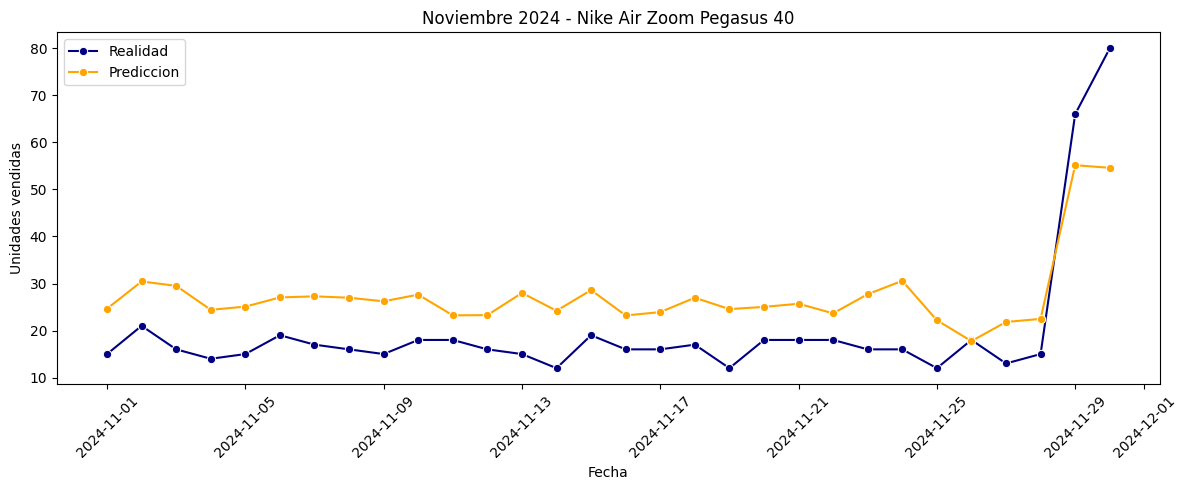

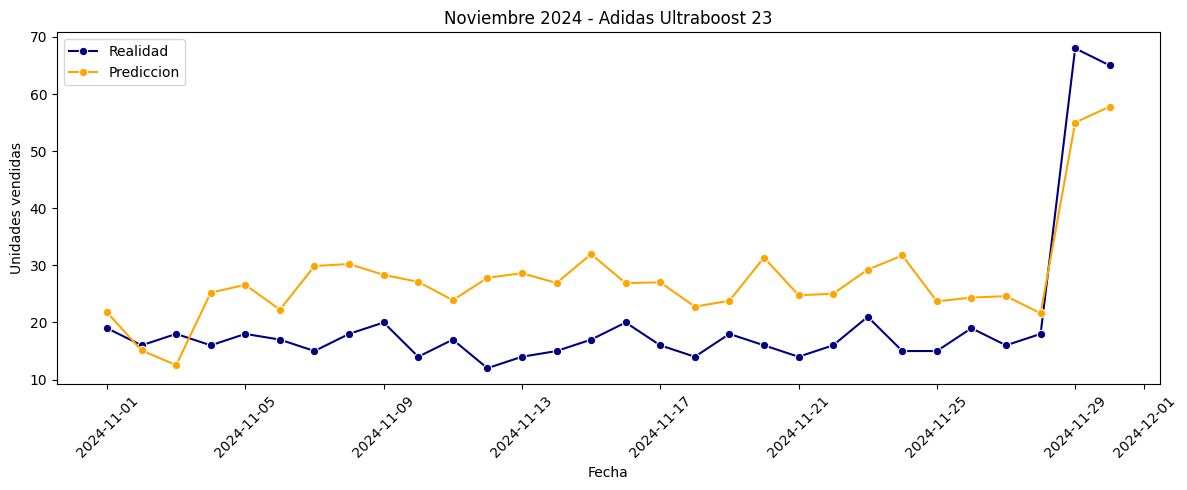

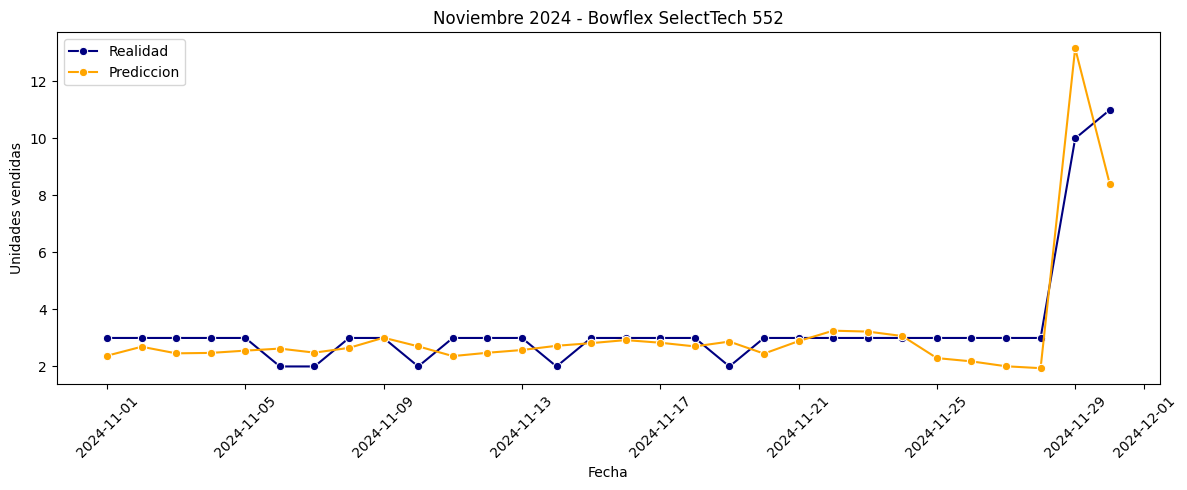

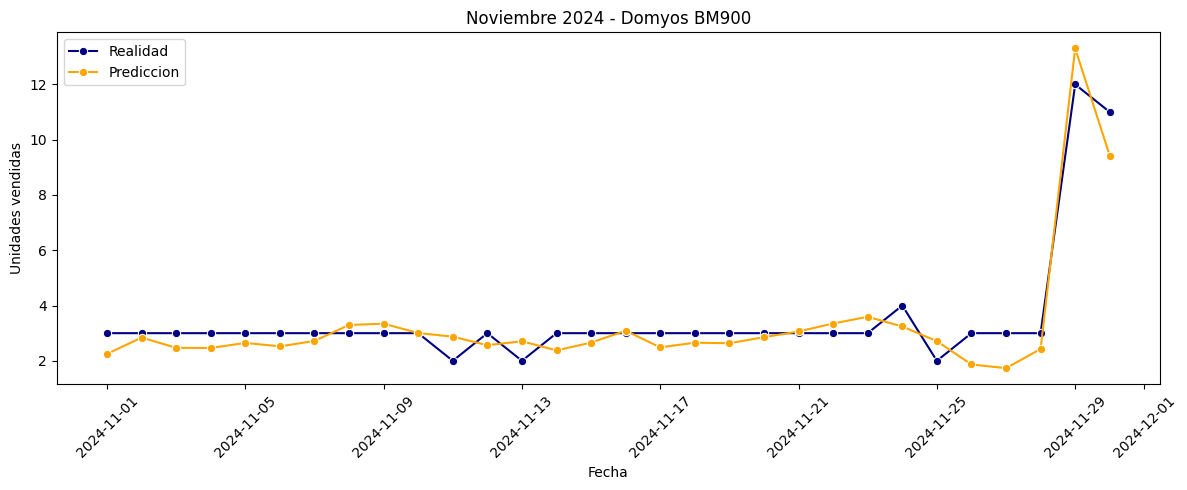

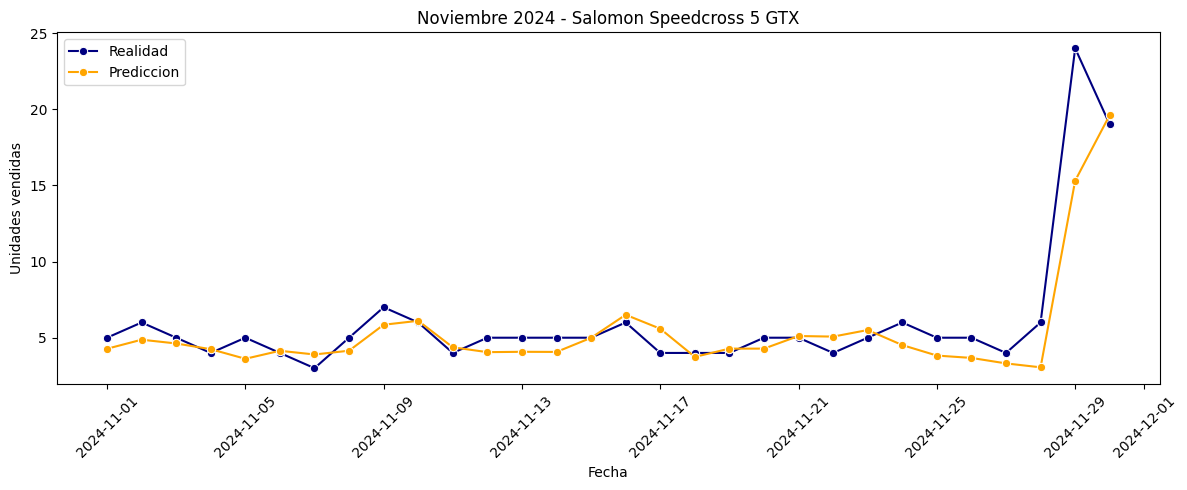

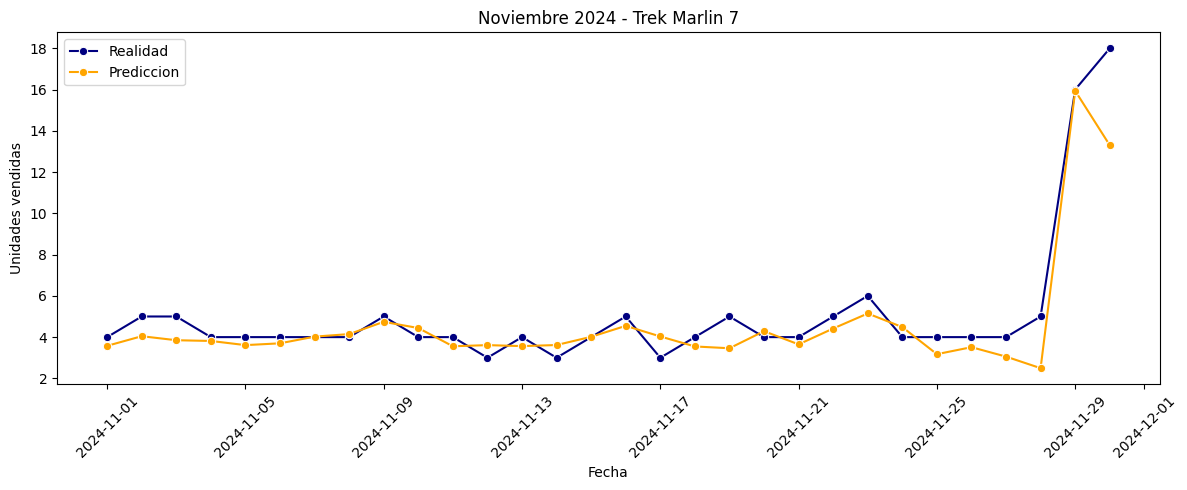

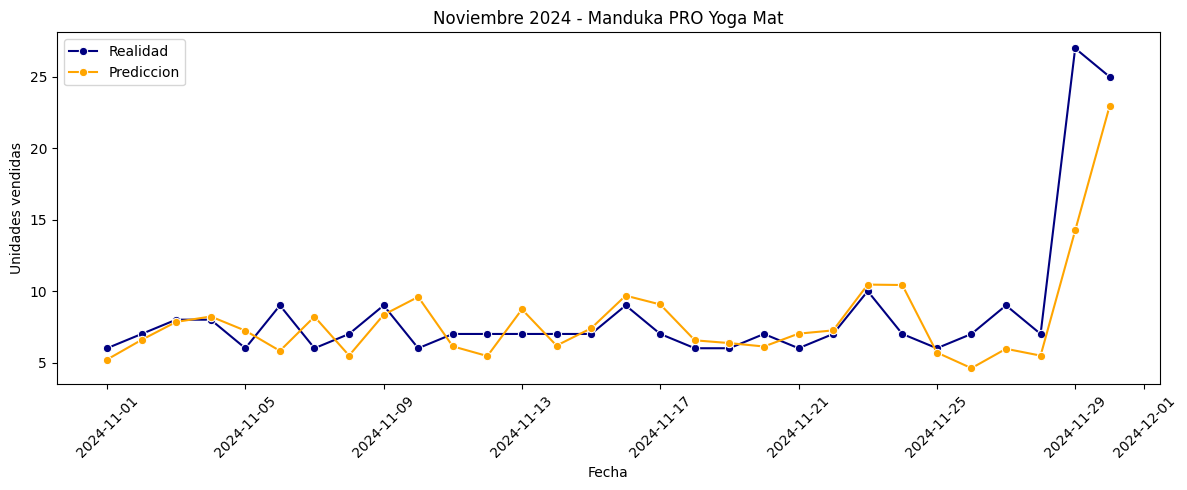

In [94]:
# Objetivo: generar predicciones para noviembre de 2024 y visualizarlas para cada producto estrella.
# Filtramos solo noviembre de 2024 dentro del conjunto de validaciÃƒÂ³n.
noviembre_2024_df = validation_df[(validation_df['anio'] == 2024) & (validation_df['mes'] == 11)].copy()

# Nos quedamos ÃƒÂºnicamente con los productos estrella.
noviembre_estrella_df = noviembre_2024_df[noviembre_2024_df['es_estrella'] == True].copy()

# Aplicamos el modelo usando las mismas variables predictoras seleccionadas en el entrenamiento.
X_noviembre_estrella = noviembre_estrella_df[variables_predictoras].copy()
noviembre_estrella_df['prediccion_unidades_vendidas'] = modelo_hgbr.predict(X_noviembre_estrella)

# Mostramos una tabla base para revisar las predicciones generadas.
display(noviembre_estrella_df[['fecha', 'producto_id', 'nombre', 'unidades_vendidas', 'prediccion_unidades_vendidas']].head(20))

# Recorremos cada producto estrella y dibujamos su serie real frente a la predicciÃƒÂ³n.
for producto_id, producto_df in noviembre_estrella_df.groupby('producto_id'):
    producto_df = producto_df.sort_values('fecha').copy()
    nombre_producto = producto_df['nombre'].iloc[0]

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=producto_df, x='fecha', y='unidades_vendidas', label='Realidad', marker='o', color='navy')
    sns.lineplot(data=producto_df, x='fecha', y='prediccion_unidades_vendidas', label='Prediccion', marker='o', color='orange')
    plt.title(f'Noviembre 2024 - {nombre_producto}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [95]:
# Objetivo: calcular el MAE de noviembre de 2024 para cada producto estrella.
# Agrupamos por producto para medir el error medio absoluto de forma individual.
mae_productos_estrella = (
    noviembre_estrella_df.groupby(['producto_id', 'nombre'], as_index=False)
    .apply(lambda grupo: pd.Series({
        'mae': mean_absolute_error(grupo['unidades_vendidas'], grupo['prediccion_unidades_vendidas'])
    }))
    .sort_values('mae')
)

display(mae_productos_estrella)


C:\Users\edgar\AppData\Local\Temp\ipykernel_29304\3625004431.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grupo: pd.Series({


,producto_id,nombre,mae
3,PROD_010,Domyos BM900,0.549797
2,PROD_009,Bowflex SelectTech 552,0.635312
5,PROD_016,Trek Marlin 7,0.732036
4,PROD_015,Salomon Speedcross 5 GTX,1.072317
6,PROD_021,Manduka PRO Yoga Mat,1.701157
1,PROD_002,Adidas Ultraboost 23,9.469951
0,PROD_001,Nike Air Zoom Pegasus 40,9.928520


In [ ]:
# Objetivo: analizar cómo evoluciona el error del modelo a lo largo de noviembre de 2024.
# Dividimos el mes en tres periodos de 10 días y calculamos métricas por tramo.
noviembre_estrella_df = noviembre_estrella_df.copy()
noviembre_estrella_df['dia_mes'] = noviembre_estrella_df['fecha'].dt.day

def asignar_periodo(dia):
    if dia <= 10:
        return 'Dias 1-10'
    elif dia <= 20:
        return 'Dias 11-20'
    else:
        return 'Dias 21-30'

noviembre_estrella_df['periodo_noviembre'] = noviembre_estrella_df['dia_mes'].apply(asignar_periodo)

metricas_periodo = (
    noviembre_estrella_df.groupby('periodo_noviembre')
    .apply(lambda grupo: pd.Series({
        'MAE': mean_absolute_error(grupo['unidades_vendidas'], grupo['prediccion_unidades_vendidas']),
        'RMSE': np.sqrt(mean_squared_error(grupo['unidades_vendidas'], grupo['prediccion_unidades_vendidas'])),
        'MAPE': (np.abs((grupo.loc[grupo['unidades_vendidas'] != 0, 'unidades_vendidas'] - grupo.loc[grupo['unidades_vendidas'] != 0, 'prediccion_unidades_vendidas']) / grupo.loc[grupo['unidades_vendidas'] != 0, 'unidades_vendidas']).mean() * 100) if (grupo['unidades_vendidas'] != 0).sum() > 0 else np.nan,
        'R2': r2_score(grupo['unidades_vendidas'], grupo['prediccion_unidades_vendidas'])
    }))
    .reset_index()
)

orden_periodos = ['Dias 1-10', 'Dias 11-20', 'Dias 21-30']
metricas_periodo['periodo_noviembre'] = pd.Categorical(metricas_periodo['periodo_noviembre'], categories=orden_periodos, ordered=True)
metricas_periodo = metricas_periodo.sort_values('periodo_noviembre')

display(metricas_periodo)

plt.figure(figsize=(12, 5))
sns.lineplot(data=metricas_periodo, x='periodo_noviembre', y='MAE', marker='o', label='MAE', color='navy')
sns.lineplot(data=metricas_periodo, x='periodo_noviembre', y='RMSE', marker='o', label='RMSE', color='orange')
plt.title('Evolucion del error por periodo - Noviembre 2024')
plt.xlabel('Periodo de noviembre')
plt.ylabel('Valor de la metrica')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.lineplot(data=metricas_periodo, x='periodo_noviembre', y='MAPE', marker='o', label='MAPE', color='crimson')
plt.title('Evolucion del MAPE por periodo - Noviembre 2024')
plt.xlabel('Periodo de noviembre')
plt.ylabel('MAPE (%)')
plt.tight_layout()
plt.show()


In [ ]:
# Objetivo: analizar la evolucion del error por producto estrella a lo largo de noviembre de 2024.
# Dividimos el mes en tres periodos de 10 dias y calculamos metricas por producto y por tramo.
noviembre_estrella_periodos_df = noviembre_estrella_df.copy()
noviembre_estrella_periodos_df['dia_mes'] = noviembre_estrella_periodos_df['fecha'].dt.day

def asignar_periodo_producto(dia):
    if dia <= 10:
        return 'Dias 1-10'
    elif dia <= 20:
        return 'Dias 11-20'
    else:
        return 'Dias 21-30'

noviembre_estrella_periodos_df['periodo_noviembre'] = noviembre_estrella_periodos_df['dia_mes'].apply(asignar_periodo_producto)

metricas_producto_periodo = (
    noviembre_estrella_periodos_df.groupby(['producto_id', 'nombre', 'periodo_noviembre'])
    .apply(lambda grupo: pd.Series({
        'MAE': mean_absolute_error(grupo['unidades_vendidas'], grupo['prediccion_unidades_vendidas']),
        'RMSE': np.sqrt(mean_squared_error(grupo['unidades_vendidas'], grupo['prediccion_unidades_vendidas'])),
        'MAPE': (np.abs((grupo.loc[grupo['unidades_vendidas'] != 0, 'unidades_vendidas'] - grupo.loc[grupo['unidades_vendidas'] != 0, 'prediccion_unidades_vendidas']) / grupo.loc[grupo['unidades_vendidas'] != 0, 'unidades_vendidas']).mean() * 100) if (grupo['unidades_vendidas'] != 0).sum() > 0 else np.nan,
        'R2': r2_score(grupo['unidades_vendidas'], grupo['prediccion_unidades_vendidas'])
    }))
    .reset_index()
)

orden_periodos = ['Dias 1-10', 'Dias 11-20', 'Dias 21-30']
metricas_producto_periodo['periodo_noviembre'] = pd.Categorical(metricas_producto_periodo['periodo_noviembre'], categories=orden_periodos, ordered=True)
metricas_producto_periodo = metricas_producto_periodo.sort_values(['nombre', 'periodo_noviembre'])

display(metricas_producto_periodo)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=metricas_producto_periodo,
    x='periodo_noviembre',
    y='MAE',
    hue='nombre',
    marker='o'
)
plt.title('Evolucion del MAE por producto estrella y periodo - Noviembre 2024')
plt.xlabel('Periodo de noviembre')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.legend(title='Producto', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
# Objetivo: analizar especificamente Black Friday 2024 para todos los productos.
# Filtramos el dataframe de validacion para quedarnos solo con Black Friday de 2024.
black_friday_2024_df = validation_df[(validation_df['anio'] == 2024) & (validation_df['es_black_friday'] == True)].copy()

# Aplicamos el modelo usando las mismas variables predictoras del entrenamiento.
X_black_friday_2024 = black_friday_2024_df[variables_predictoras].copy()
black_friday_2024_df['prediccion_unidades_vendidas'] = modelo_hgbr.predict(X_black_friday_2024)

# Ordenamos por producto para que la visualizacion sea mas clara.
black_friday_2024_df = black_friday_2024_df.sort_values('producto_id').copy()

# Mostramos una tabla base para revisar los valores reales y predichos.
display(black_friday_2024_df[['producto_id', 'nombre', 'unidades_vendidas', 'prediccion_unidades_vendidas']])

plt.figure(figsize=(16, 6))
sns.lineplot(data=black_friday_2024_df, x='producto_id', y='unidades_vendidas', marker='o', label='Realidad', color='navy')
sns.lineplot(data=black_friday_2024_df, x='producto_id', y='prediccion_unidades_vendidas', marker='o', label='Prediccion', color='orange')
plt.title('Black Friday 2024 - Realidad vs Prediccion por producto')
plt.xlabel('Producto ID')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Entrenamiento final
En esta sección realizamos el entrenamiento final del modelo después de la fase de validación. Técnicamente, reutilizamos las mismas variables predictoras y los mismos hiperparámetros óptimos seleccionados para ajustar una versión definitiva del modelo.
Desde negocio, esto permite aprovechar al máximo todo el histórico disponible antes de generar predicciones futuras, incorporando la información completa observada entre 2021 y 2024.


In [ ]:
# Objetivo: reentrenar el modelo final con todo el historico disponible.
# Reutilizamos las mismas variables predictoras y los mismos hiperparametros validados anteriormente.
variable_objetivo = 'unidades_vendidas'

X_final = df[variables_predictoras].copy()
y_final = df[variable_objetivo].copy()

modelo_final = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=500,
    max_depth=5,
    min_samples_leaf=30,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

modelo_final.fit(X_final, y_final)

print('Modelo final entrenado correctamente con todo el historico disponible.')
print(f'Registros usados en el entrenamiento final: {len(df)}')
print(f'Numero de variables predictoras reutilizadas: {len(variables_predictoras)}')


,feature,importance_mean
33,lag_1,1.824948
41,descuento_porcentaje,0.703558
39,lag_7,0.244615
40,media_movil_7_dias,0.235607
5,es_black_friday,0.192709
...,...,...
412,subcategoria_h_Esterilla Yoga,0.000000
411,subcategoria_h_Esterilla Yoga,0.000000
410,subcategoria_h_Esterilla Yoga,0.000000
409,subcategoria_h_Esterilla Fitness,0.000000


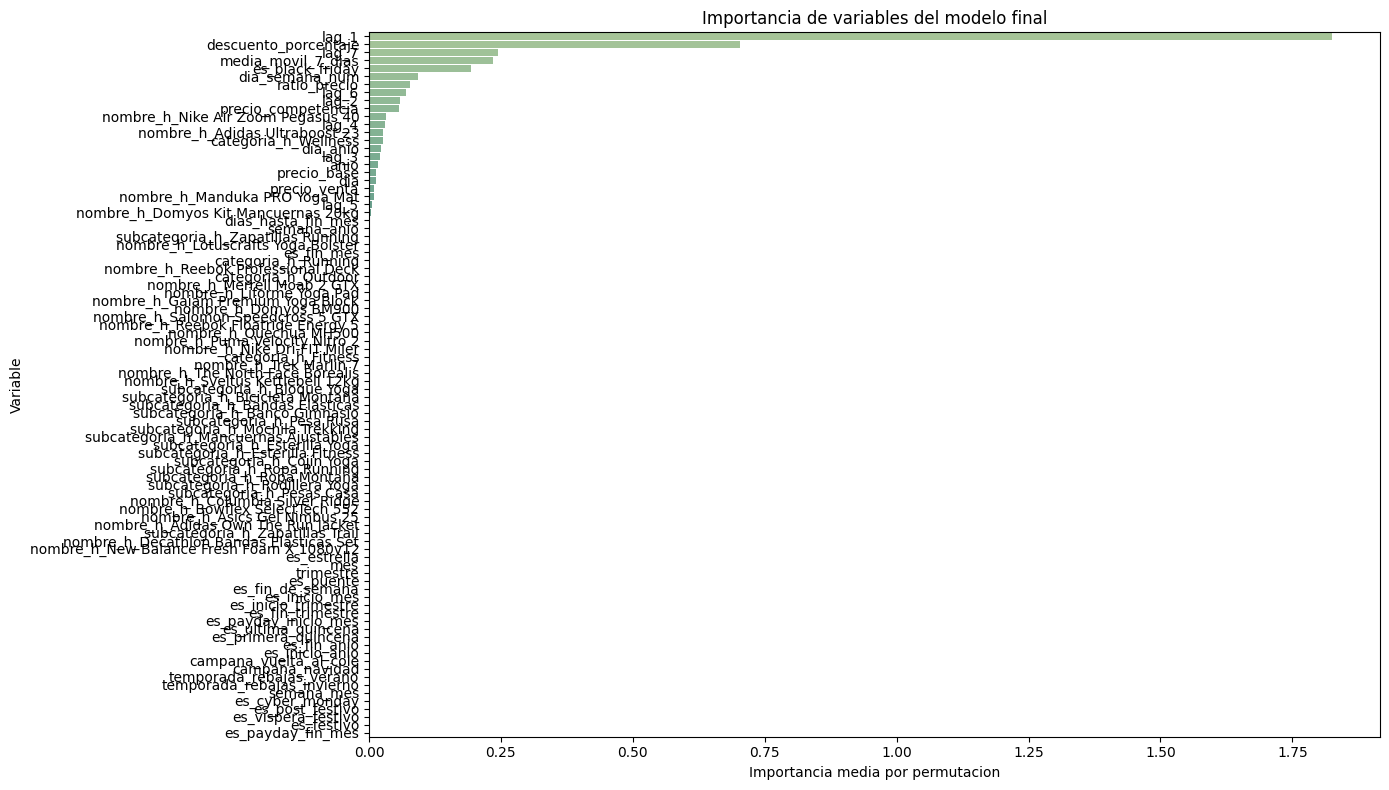

Modelo final guardado en: models\modelofinal.joblib


In [100]:
# Objetivo: interpretar la importancia de variables del modelo final y guardarlo en disco.
from sklearn.inspection import permutation_importance
from pathlib import Path
import joblib

# Usamos las mismas variables predictoras empleadas en el entrenamiento final.
resultado_importancia = permutation_importance(
    modelo_final,
    X_final,
    y_final,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_absolute_error'
)

importancia_variables_df = pd.DataFrame({
    'feature': X_final.columns,
    'importance_mean': resultado_importancia.importances_mean
}).sort_values('importance_mean', ascending=False)

display(importancia_variables_df)

plt.figure(figsize=(14, 8))
sns.barplot(data=importancia_variables_df, x='importance_mean', y='feature', hue='feature', dodge=False, palette='crest', legend=False)
plt.title('Importancia de variables del modelo final')
plt.xlabel('Importancia media por permutacion')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

# Guardamos el modelo final en la carpeta models.
ruta_modelo = Path('models/modelofinal.joblib')
ruta_modelo.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(modelo_final, ruta_modelo)

print(f'Modelo final guardado en: {ruta_modelo}')
